<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/03_Airbnb_Berlin_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install missingno
# !pip install geopy

In [2]:
# !pip install missingno
# !pip install geopy
# !pip install matplotlib

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df_EDA2 = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')


## Declare data columns Lists

In [6]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
num_non_dummy_columns = numerical_columns + rating_columns + categorical_encoded_columns + geo_columns

dropping 'Listing ID'and duplciated'Neighbourhood Grouped'

In [7]:
df = df_EDA2.copy()
df = df.drop(columns=['review_date']) ## , 'Host Since'

In [8]:
df.shape, df.index[-1]

((23536, 32), 23535)

In [9]:
df.reset_index(drop=True, inplace=True)
df.shape, df.index[-1]

((23536, 32), 23535)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        18888 non-null  float64
 1   Bathrooms              23507 non-null  float64
 2   Checkin Rating         18870 non-null  float64
 3   Cleanliness Rating     18892 non-null  float64
 4   Communication Rating   18886 non-null  float64
 5   Host Response Rate     13046 non-null  float64
 6   Latitude               23536 non-null  float64
 7   Location Rating        18871 non-null  float64
 8   Longitude              23536 non-null  float64
 9   Overall Rating         18914 non-null  float64
 10  Price                  23536 non-null  float64
 11  Square Feet            425 non-null    float64
 12  Value Rating           18868 non-null  float64
 13  Comments               19378 non-null  object 
 14  Host Since             23515 non-null  object 
 15  Ho

In [11]:
df_num = df._get_numeric_data().dropna()
df_num.shape

(297, 22)

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

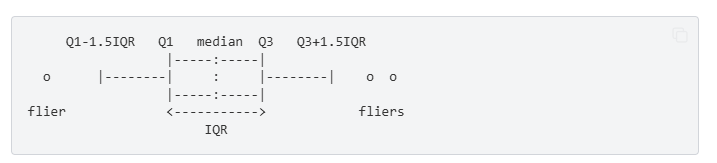

In [12]:
df_num_non_dummy = df_num.drop(columns=boolean_columns)
num_non_dummy_columns = df_num_non_dummy.columns
df_num_non_dummy.shape
num_non_dummy_columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews'],
      dtype='object')

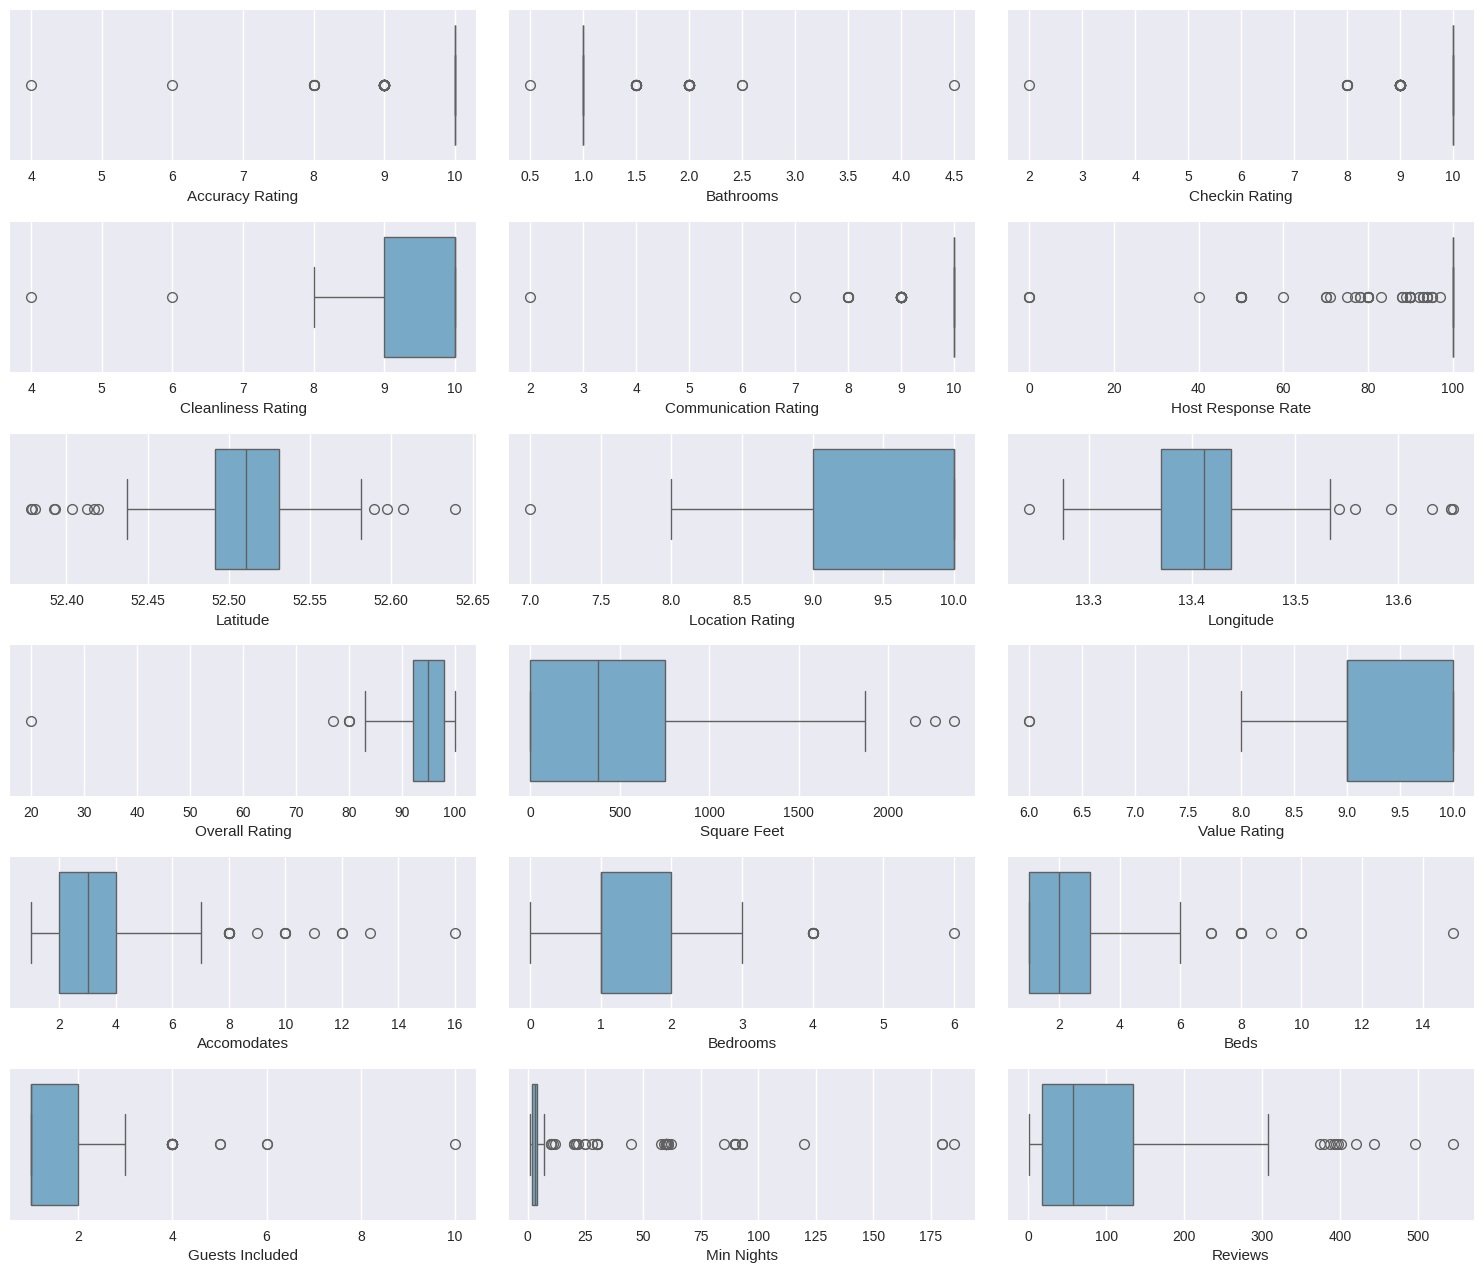

In [13]:
def outlier_boxplot(df):
  plt.figure(figsize=(15, 40))
  j = 1
  r = len(df.columns)
  for i, col in enumerate([c for c in df if c != 'Price'], 1):
    plt.subplot(r, 3, i)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)

  plt.tight_layout()
  plt.show()

outlier_boxplot(df_num_non_dummy)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Ignored as it is the target value
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [14]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in df_num_non_dummy:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=num_non_dummy_columns)

df_describe(df_num_non_dummy, num_non_dummy_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Accuracy Rating,4.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Bathrooms,0.50000,1.00000,1.00000,1.00000,4.50000,0.00000,1.000000,1.000000
Checkin Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Cleanliness Rating,4.00000,9.00000,10.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Communication Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Host Response Rate,0.00000,100.00000,100.00000,100.00000,100.00000,0.00000,100.000000,100.000000
Latitude,52.37828,52.49150,52.51037,52.53055,52.63913,0.03905,52.432925,52.589125
Location Rating,7.00000,9.00000,10.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Longitude,13.24245,13.37033,13.41194,13.43787,13.65275,0.06754,13.269020,13.539180
Overall Rating,20.00000,92.00000,95.00000,98.00000,100.00000,6.00000,83.000000,107.000000


## Data Cleansing

### outliers_df

Based on previous histograms and skewness visualizations, we can observe that the data is not normally distributed. To identify outliers, we will apply the IQR method, establishing boundaries before Q1 and after Q3. Any values falling outside these boundaries will be considered outliers.

In [15]:
def count_outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])
    # for col in df:  # Ensure processing numeric columns only
    for col in [c for c in df if c != 'Price']:  # Ensure processing numeric columns only and exclude Price
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

**Consider replacing outliers_df dataframe with only outliers_df_columns**

In [16]:
len(df_num_non_dummy.columns)

19

In [17]:
# Assume df_num_non_dummy is your DataFrame
# Call the function and sort results
outliers_df = count_outliers_df(df_num_non_dummy).sort_values('Percent', ascending=False)
outliers_df, outliers_df.shape

(                      Outlier count    Percent
 Accuracy Rating                74.0  24.915825
 Checkin Rating                 60.0  20.202020
 Host Response Rate             56.0  18.855219
 Min Nights                     53.0  17.845118
 Bathrooms                      52.0  17.508418
 Communication Rating           51.0  17.171717
 Guests Included                26.0   8.754209
 Accomodates                    20.0   6.734007
 Latitude                       13.0   4.377104
 Reviews                        11.0   3.703704
 Beds                           10.0   3.367003
 Bedrooms                        9.0   3.030303
 Longitude                       8.0   2.693603
 Overall Rating                  5.0   1.683502
 Square Feet                     3.0   1.010101
 Cleanliness Rating              2.0   0.673401
 Value Rating                    2.0   0.673401
 Location Rating                 1.0   0.336700,
 (18, 2))

In [18]:
outliers_df.to_csv('/content/drive/My Drive/Airbnb/outliers_df.csv')

### new_df_outliers - labeling with 'Outlier'
Labeling every outlier with 'Outlier'

In [19]:
outliers_df.index

Index(['Accuracy Rating', 'Checkin Rating', 'Host Response Rate', 'Min Nights',
       'Bathrooms', 'Communication Rating', 'Guests Included', 'Accomodates',
       'Latitude', 'Reviews', 'Beds', 'Bedrooms', 'Longitude',
       'Overall Rating', 'Square Feet', 'Cleanliness Rating', 'Value Rating',
       'Location Rating'],
      dtype='object')

In [20]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit, 'Outlier',
                                         np.where(label_out_df[col] < lower_limit,
                                                  'Outlier', label_out_df[col]))
    return label_out_df

new_df_outliers = outliers(df)
new_df_outliers.head(5)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,Outlier,52.54851,9.0,13.40455,100.0,17.0,nan,10.0,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,1.0,1,2,7,Apartment,10
1,Outlier,1.0,Outlier,9.0,Outlier,Outlier,52.535,10.0,13.41758,92.0,90.0,720.0,9.0,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4,1.0,2.0,Outlier,Outlier,Outlier,Apartment,10
2,10.0,1.0,10.0,10.0,10.0,100.0,52.54316,10.0,13.41509,96.0,33.0,nan,10.0,I could not have asked for a better place to s...,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,2.0,1,2,Outlier,Apartment,10
3,10.0,Outlier,10.0,10.0,10.0,100.0,52.53303,10.0,13.41605,100.0,180.0,nan,10.0,The host was very welcoming and hospitable. He...,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Outlier,Outlier,Outlier,Outlier,6,6,Apartment,10
4,10.0,1.0,Outlier,10.0,10.0,100.0,52.54785,9.0,13.40556,93.0,70.0,nan,9.0,"We had everything we needed, the apartment was...",11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,1,Outlier,1.0,1,Outlier,23,Apartment,10


### df_outliers - 0/1

Creating a dataframe with outliers as 1 and non-outliers as 0:

In [21]:
df_outliers = new_df_outliers.isin(['Outlier'])
df_outliers = df_outliers.astype('int')
df_outliers

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
23532,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
23533,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0


Now that we have a dataframe saving all the outliers we'll convert all the outliers to nulls, just so I can see differences in distribution with and without outliers and then decide which of the outliers to remove or not:

In [22]:
def capping(df):
    temp = df.copy()
    for col in temp:
        if col in outliers_df.index:
            Q1 = temp[col].quantile(0.25)
            Q3 = temp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            temp[col] = np.where(temp[col] > upper_limit,np.nan,np.where(temp[col] < lower_limit,np.nan,temp[col]))
    return temp
temp = capping(df)
temp

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,NaN,52.54851,9.0,13.40455,100.0,17.0,NaN,10.0,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2.0,1.0,1.0,1.0,2.0,7.0,Apartment,10
1,NaN,1.0,NaN,9.0,NaN,NaN,52.53500,10.0,13.41758,92.0,90.0,720.0,9.0,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4.0,1.0,2.0,NaN,NaN,NaN,Apartment,10
2,10.0,1.0,10.0,10.0,10.0,100.0,52.54316,10.0,13.41509,96.0,33.0,NaN,10.0,I could not have asked for a better place to s...,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2.0,1.0,2.0,1.0,2.0,NaN,Apartment,10
3,10.0,NaN,10.0,10.0,10.0,100.0,52.53303,10.0,13.41605,100.0,180.0,NaN,10.0,The host was very welcoming and hospitable. He...,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,NaN,NaN,NaN,NaN,6.0,6.0,Apartment,10
4,10.0,1.0,NaN,10.0,10.0,100.0,52.54785,9.0,13.40556,93.0,70.0,NaN,9.0,"We had everything we needed, the apartment was...",11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,1.0,NaN,1.0,1.0,NaN,23.0,Apartment,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,NaN,NaN,None,10-23-18,within a few hours,False,Wannsee,Steglitz - Zehlendorf,14109,False,Apartment,Entire home/apt,True,3.0,1.0,2.0,1.0,NaN,0.0,Apartment,14
23532,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,13.49340,NaN,30.0,NaN,NaN,None,05-13-19,None,False,Mitte,Pankow,13125,True,Apartment,Private room,True,2.0,NaN,2.0,NaN,5.0,0.0,Apartment,13
23533,NaN,NaN,NaN,NaN,NaN,NaN,52.45402,NaN,13.43864,NaN,17.0,NaN,NaN,None,07-31-14,None,False,Britz,NeukÃ¶lln,12347,True,Apartment,Private room,True,1.0,1.0,1.0,1.0,2.0,0.0,Apartment,12
23534,NaN,1.0,NaN,NaN,NaN,NaN,52.47342,NaN,NaN,NaN,52.0,NaN,NaN,None,05-13-19,None,False,KÃ¶penick,Treptow - KÃ¶penick,12555,True,Apartment,Entire home/apt,True,NaN,NaN,NaN,1.0,2.0,0.0,Apartment,12


In [23]:
temp.to_csv('/content/drive/My Drive/Airbnb/outliers_q_df.csv')

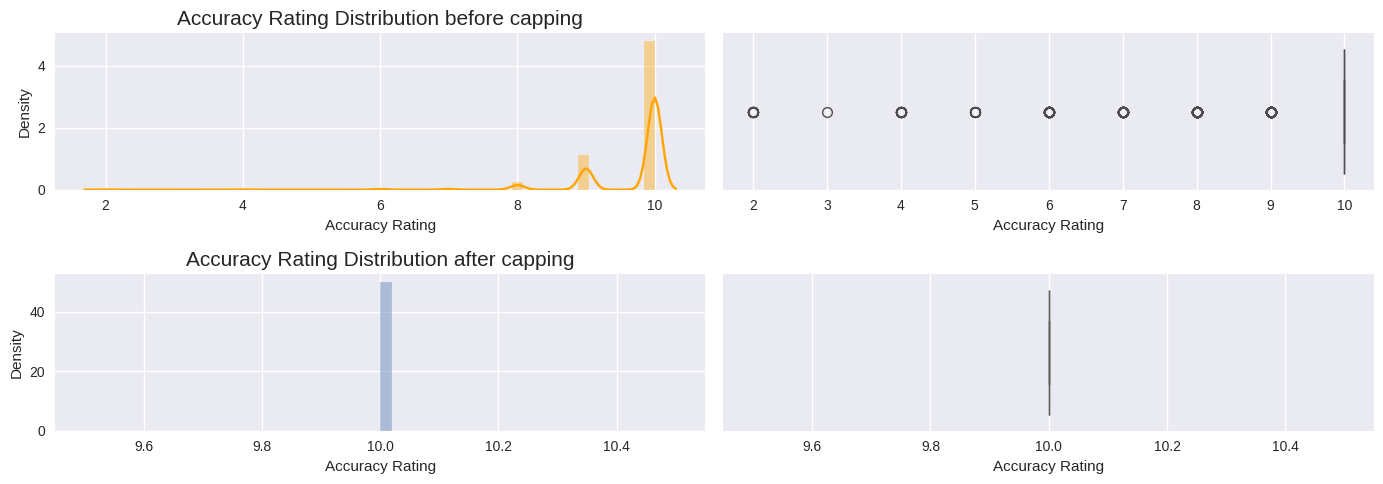

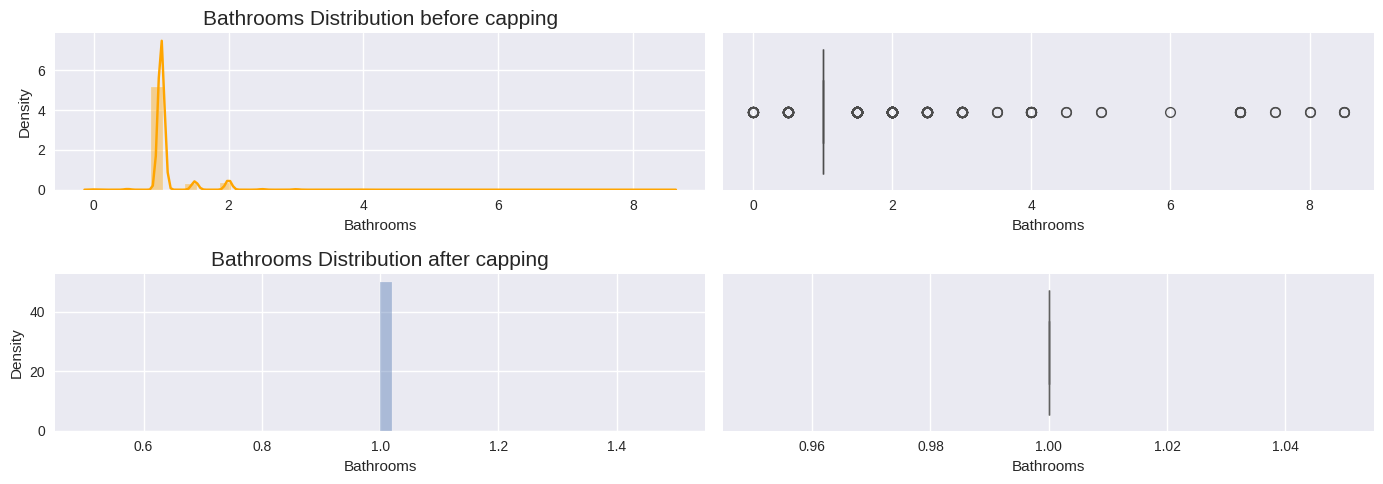

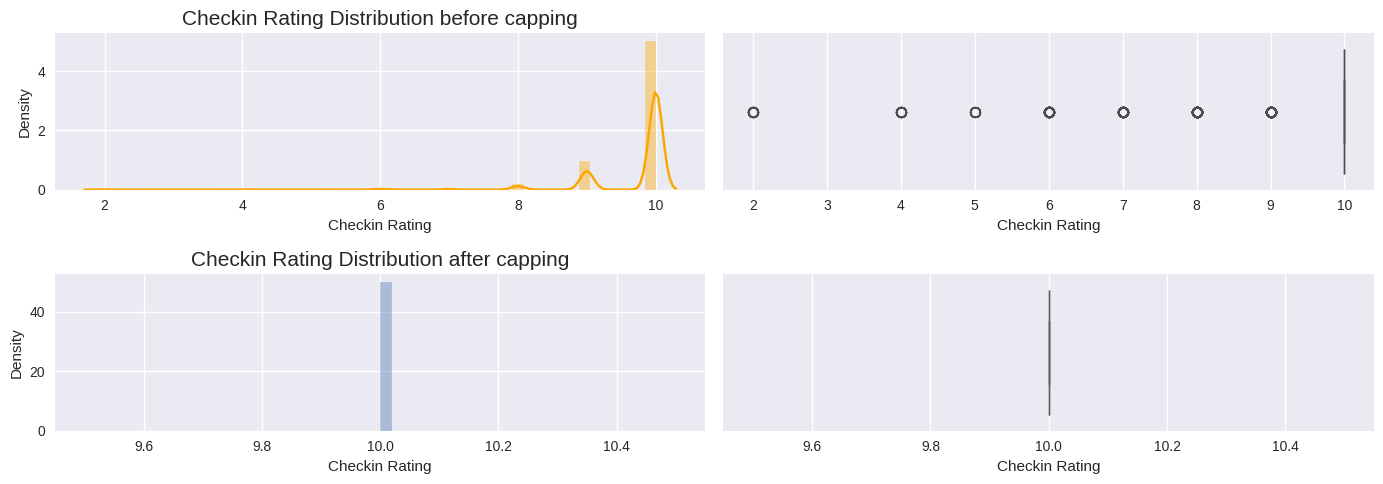

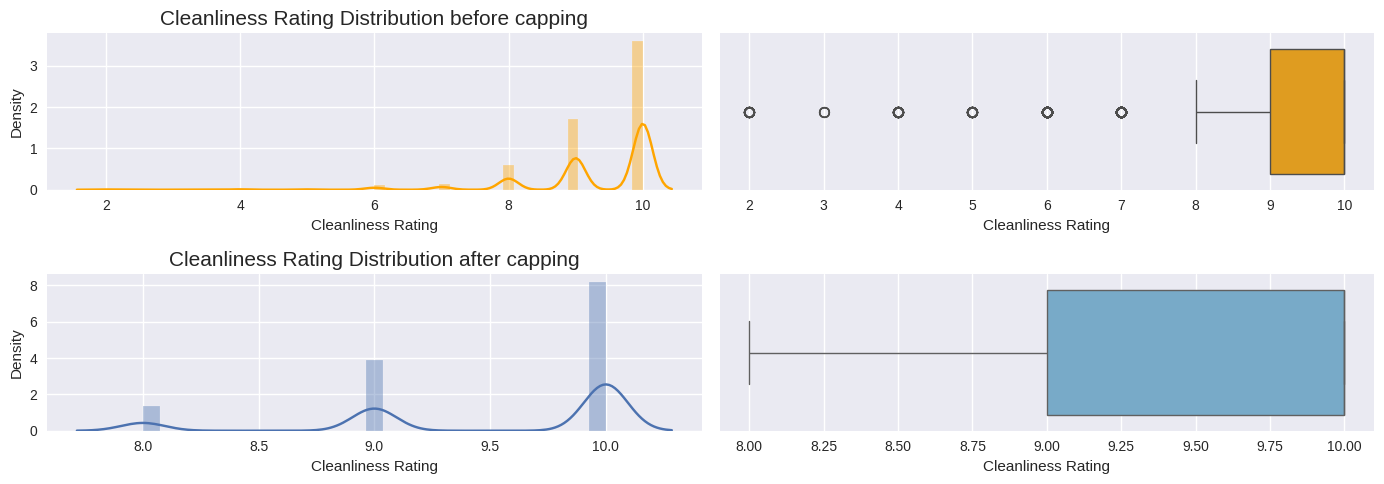

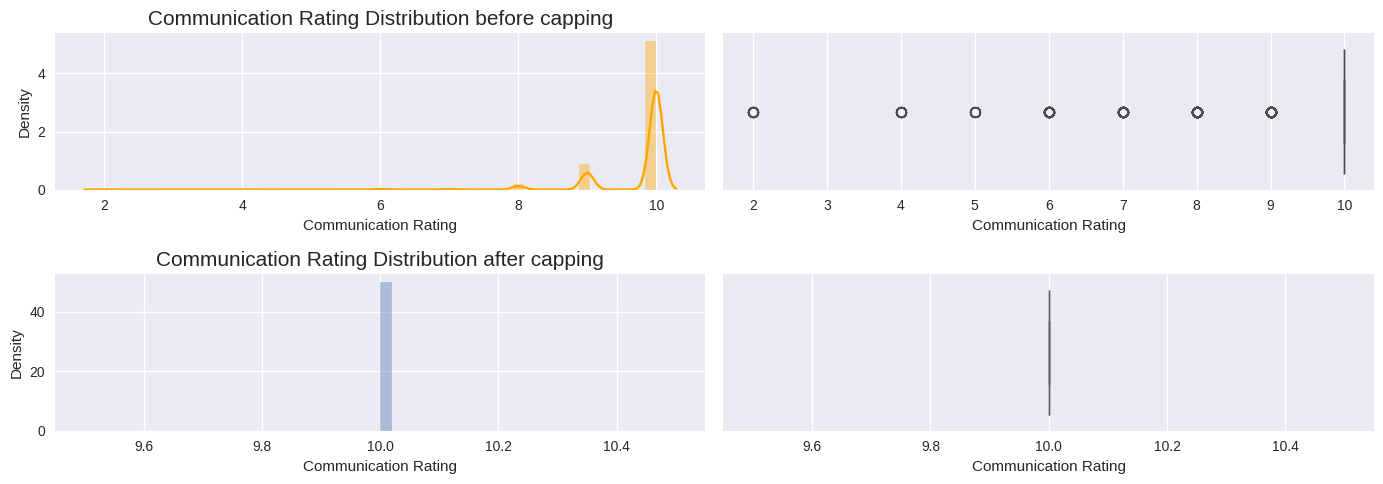

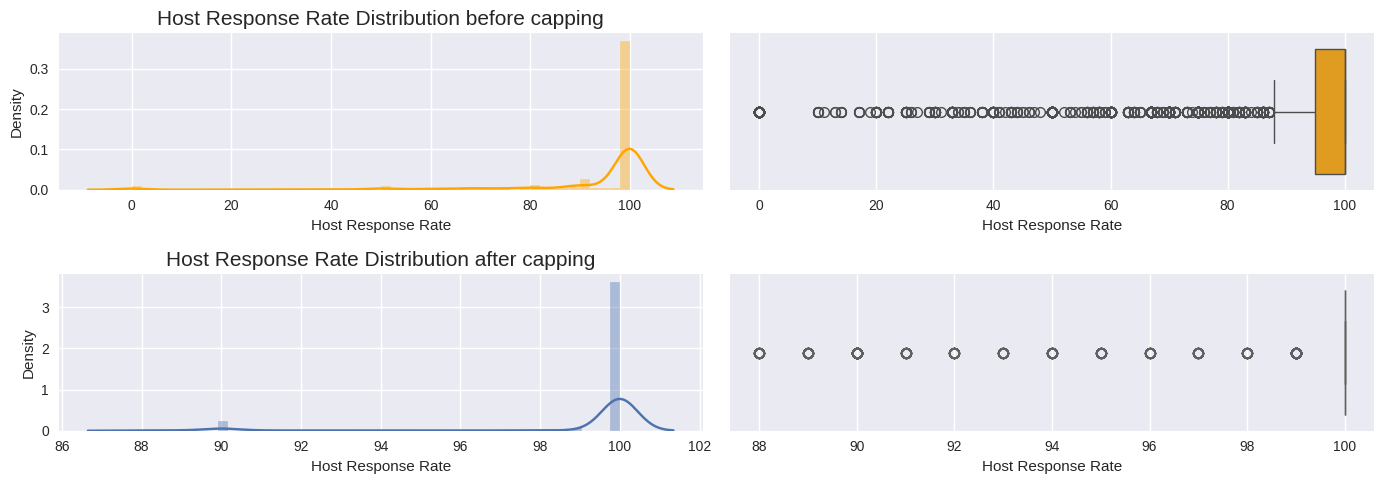

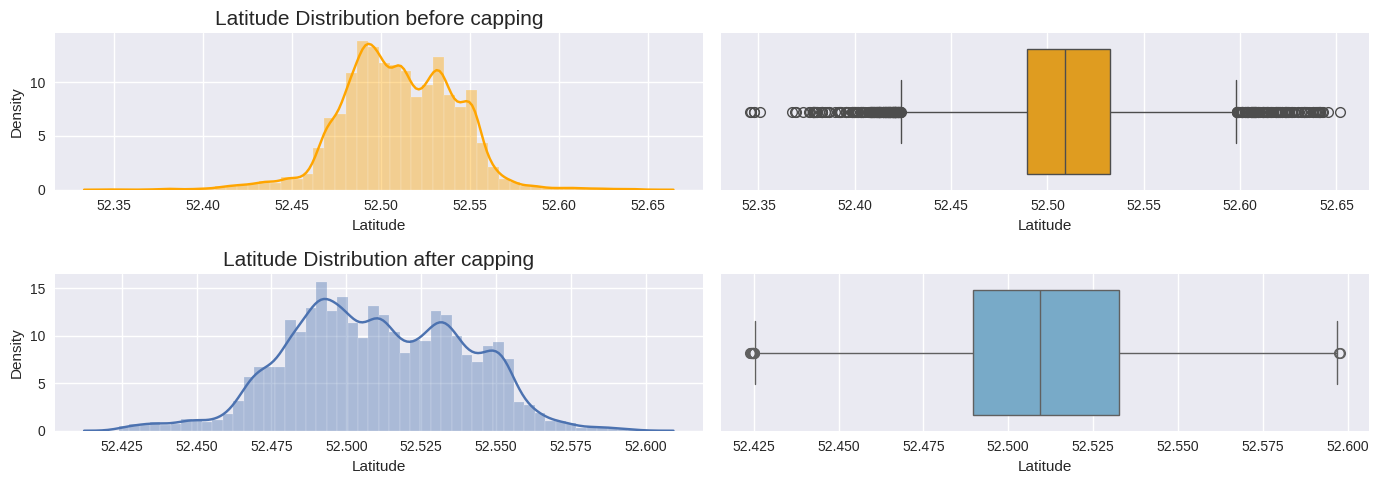

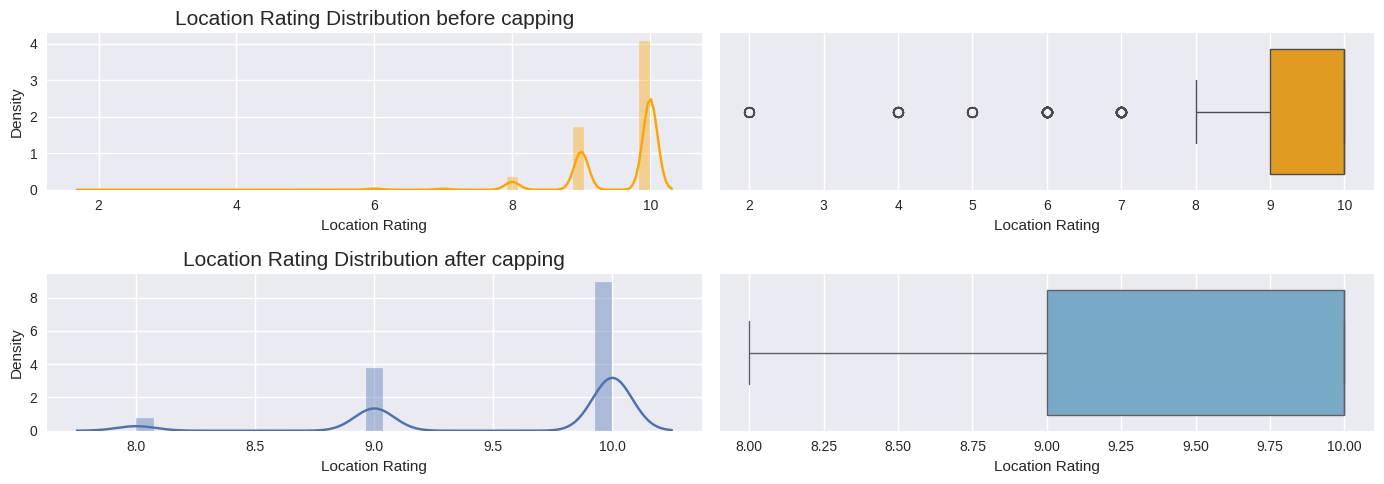

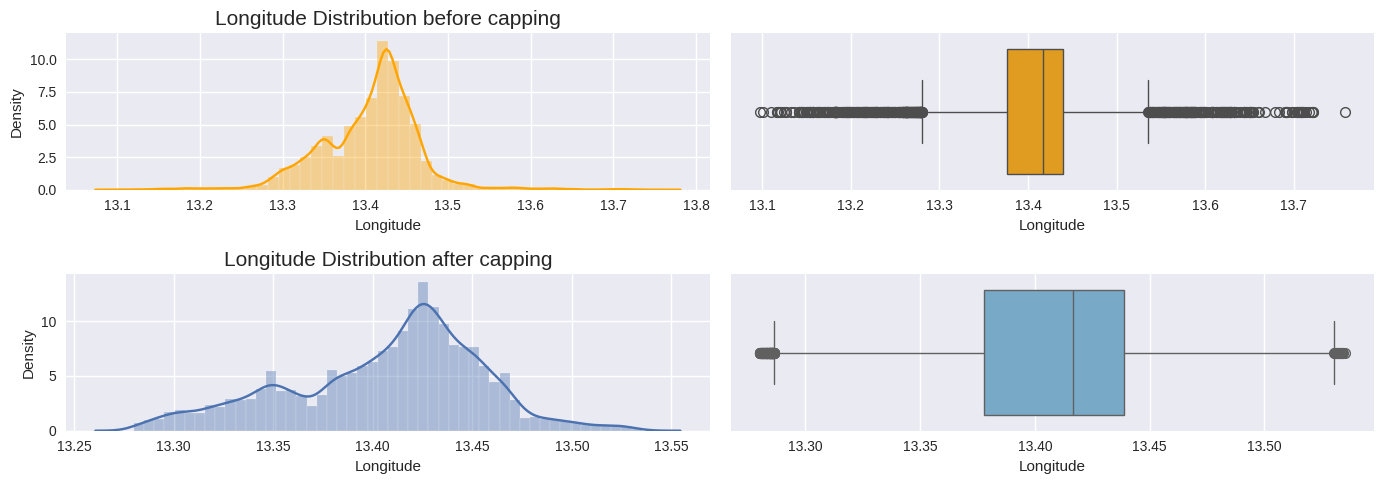

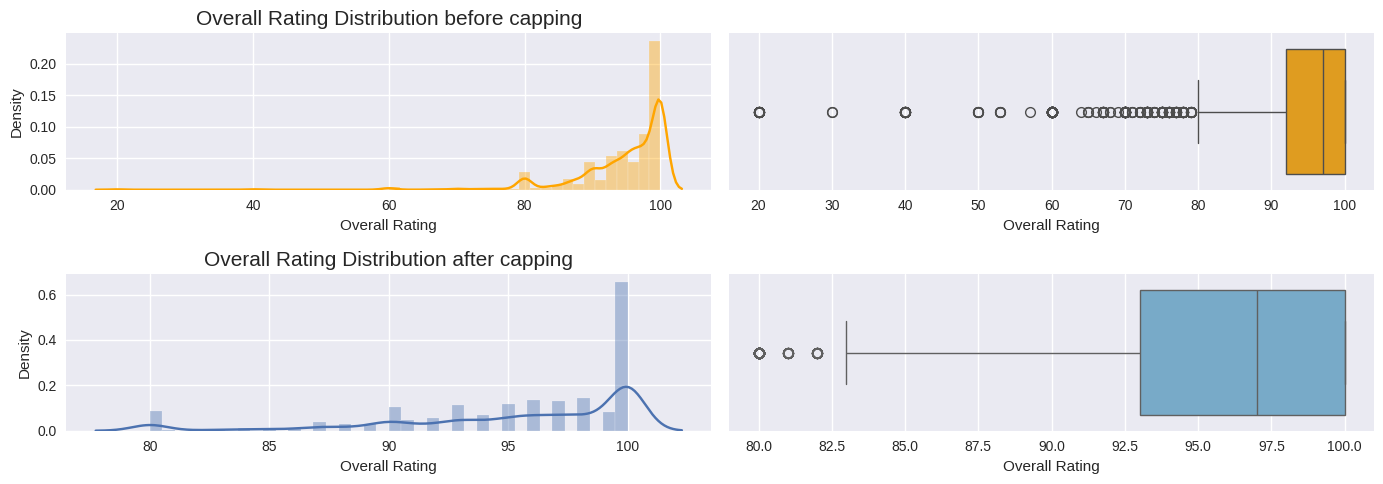

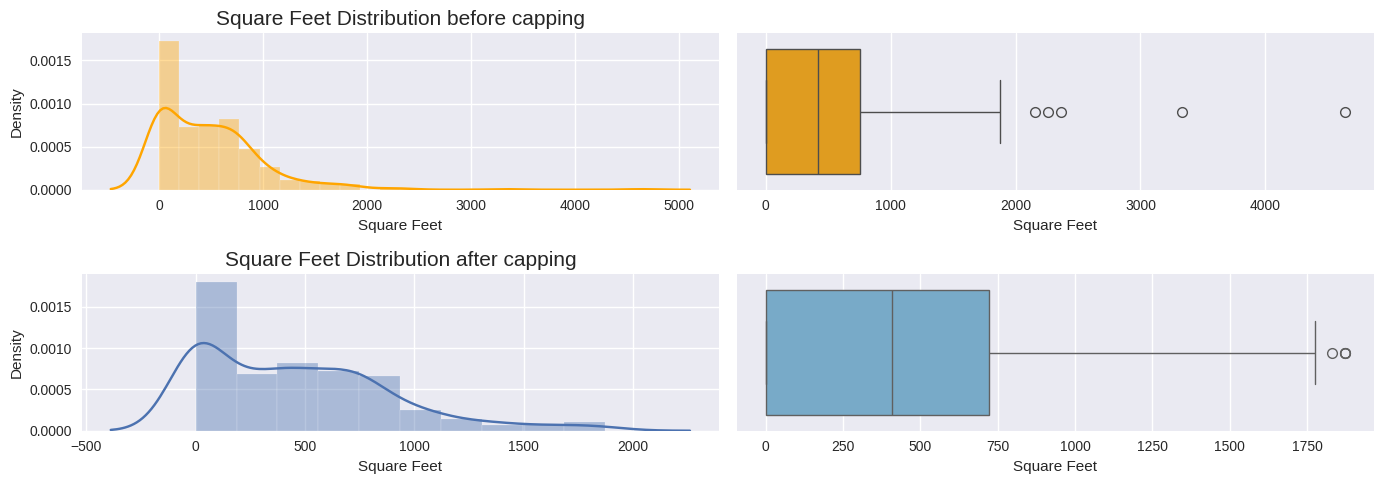

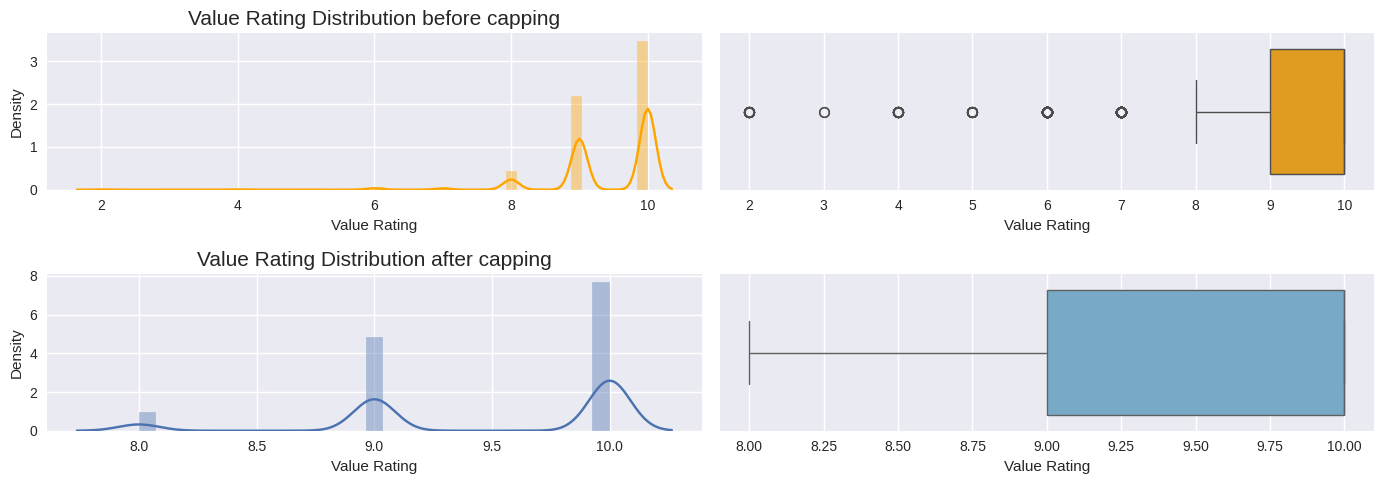

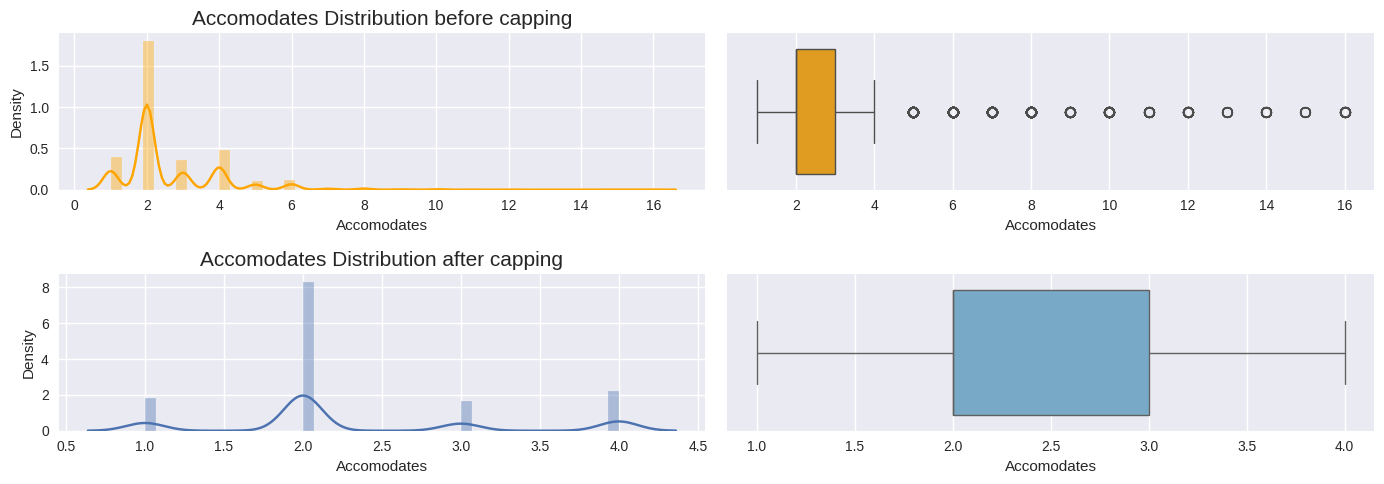

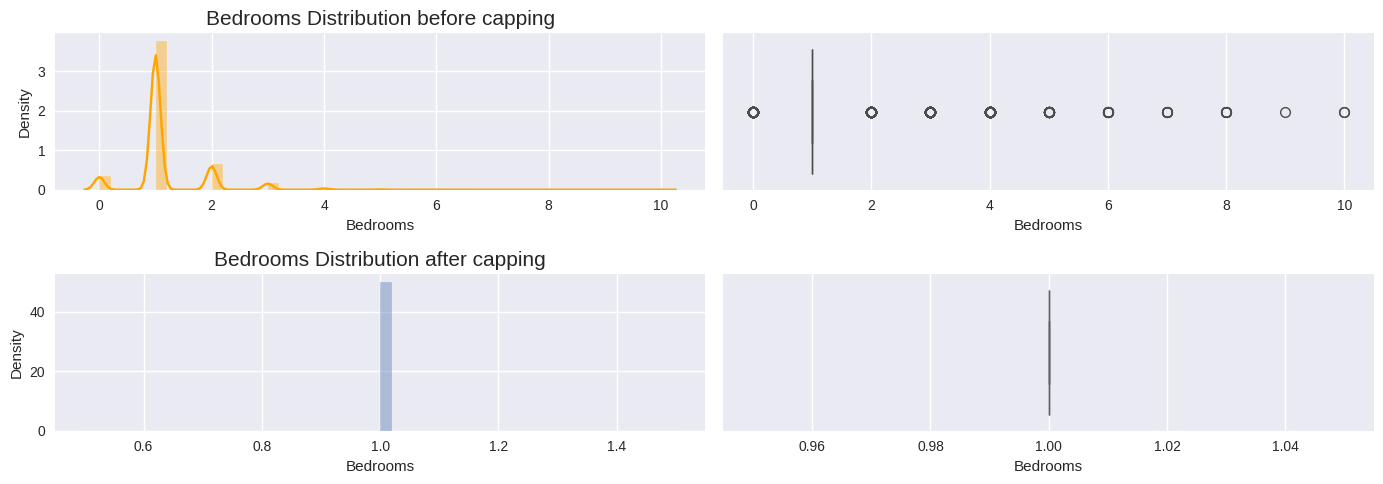

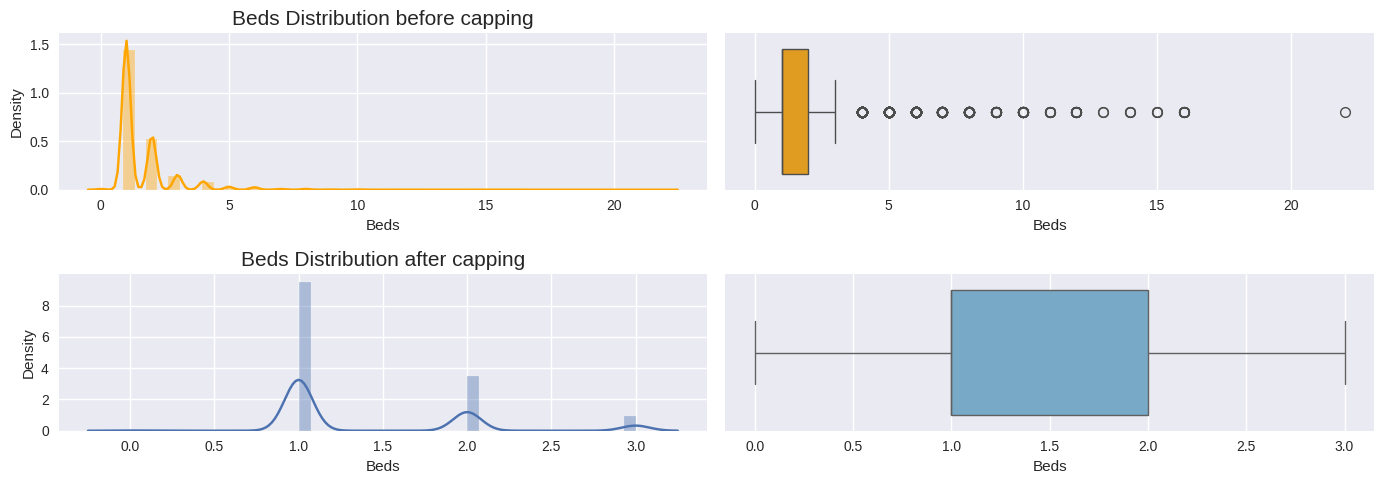

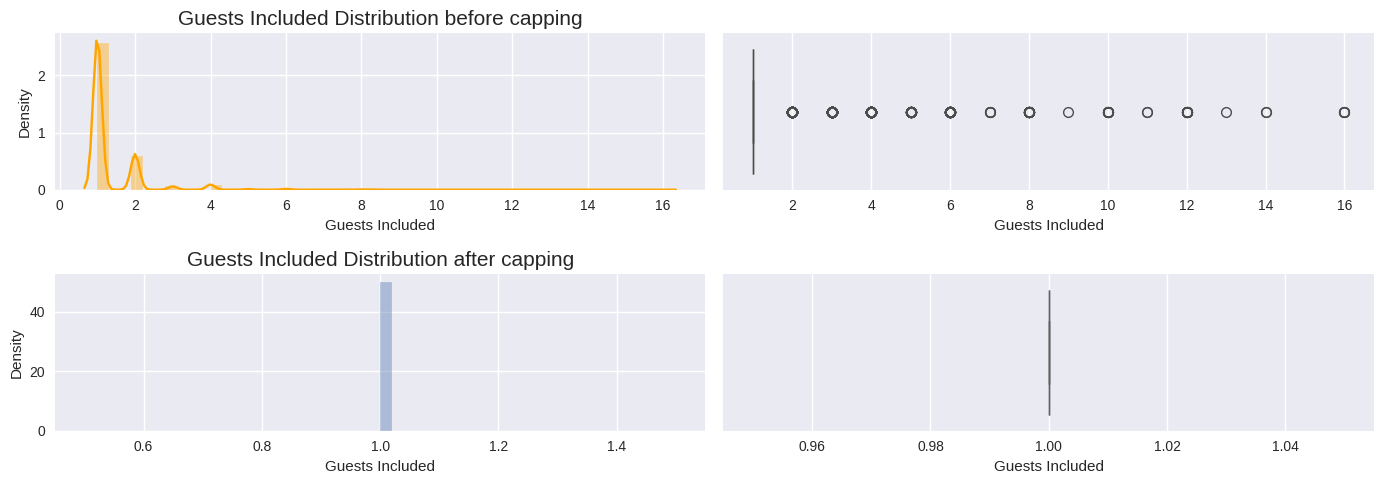

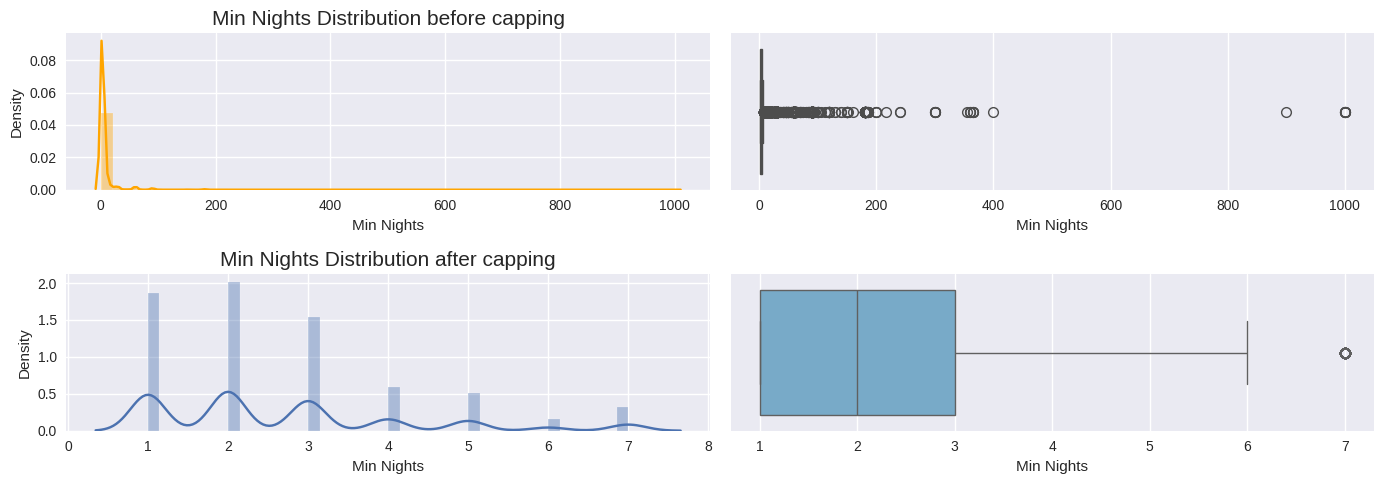

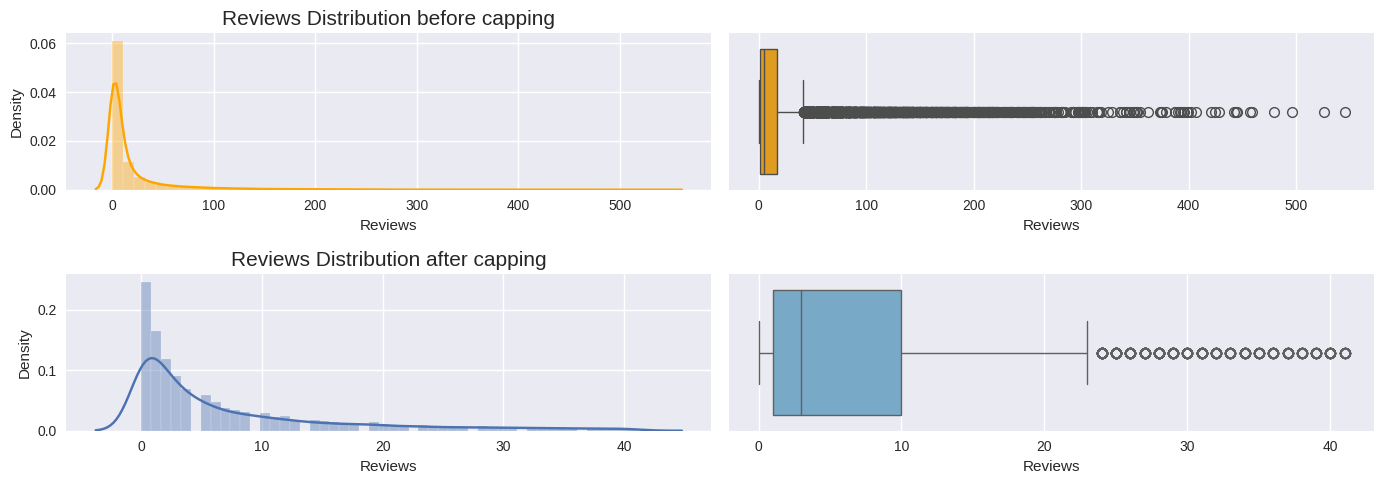

In [24]:
def dist_outliers(original_df, new, cols):
  for col in df_num_non_dummy:
      if col in cols:
        plt.figure(figsize=(14,5))

        plt.subplot(2,2,1)
        sns.distplot(original_df[col].dropna(), color='orange')
        plt.title('{} Distribution before capping'.format(col), fontsize=15)

        plt.subplot(2,2,2)
        sns.boxplot(x=original_df[col].dropna(), color='orange')
        plt.subplots_adjust(hspace = 0.6)

        plt.subplot(2,2,3)
        sns.distplot(new[col].dropna())
        plt.title('{} Distribution after capping'.format(col), fontsize=15)

        plt.subplot(2,2,4)
        sns.boxplot(x=new[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.tight_layout()
        plt.show()

dist_outliers(df, temp, outliers_df.index)

We clearly need to filter some features that either the feature distribution has changed significantly, or cases where removing outliers results with only one value.

Checking if distribution (Kolmogorov–Smirnov) and/or correlation has changed significantly:

In [25]:
corr_mattrix = df[['Price', 'Reviews']].corr(method='spearman')
corr_mattrix.Price.loc['Reviews']

np.float64(0.08775901543190176)

In [26]:
df['Price'].corr(df['Reviews'], method='spearman')

np.float64(0.08775901543190176)

In [27]:
### differences between two correlation in Python: https://github.com/psinger/CorrelationStats
### We will only take from the code the Fisher method for two-tailed test
### Z-test to Compare Two Correlations???
def cocor(x1,y1, x2,y2):
    xy1 = x1.corr(y1, method='spearman')
    xy2 = x2.corr(y2, method='spearman')
    n1 = len(x1)
    n2 = len(x2)
    xy_z = 0.5 * np.log((1 + xy1)/(1 - xy1))
    ab_z = 0.5 * np.log((1 + xy2)/(1 - xy2))
    if n2 is None:
        n2 = n1
    se_diff_r = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    diff = xy_z - ab_z
    z_score = abs(diff / se_diff_r)
    p_value = (1 - norm.cdf(z_score)) * 2
    return z_score, p_value

In [28]:
c=df_num_non_dummy.drop(columns=['Price'])
names=c.columns
#Creating df that reflects the correlation change
out_df= pd.DataFrame(columns=['feature','outliers_cnt','distribution_changed','correlation_changed'])

#A copy of numeric df
no_outliers=df_num_non_dummy.copy()
np.seterr(divide='ignore', invalid='ignore')
for i in names:
    # df with outliers
    out=df[i]
    # df with out outliers
    non=df[i].loc[new_df_outliers[i]==0]
    # lable with outliers
    price_out=df['Price']
    # lable with out outliers
    price_non=df['Price'].loc[new_df_outliers[i]==0]
    # cocor pvalue
    p, pvalue = cocor(out,price_out, non,price_non)
    cor_change=np.where(pvalue<0.05,'+','-')
    # outliers count
    mv=df_outliers.sum()
    # ks pvalue
    pval=ks_2samp(out, non)[1]
    dist_change=np.where(pval<0.05,'+','-')
    out_df = pd.concat([out_df, pd.DataFrame([{'feature':i,'outliers_cnt':mv,'distribution_changed':dist_change,'correlation_changed': cor_change}])], ignore_index=True)
out_df.head(20)

,feature,outliers_cnt,distribution_changed,correlation_changed
0,Accuracy Rating,Accuracy Rating 4367 Bathrooms ...,-,-
1,Bathrooms,Accuracy Rating 4367 Bathrooms ...,-,-
2,Checkin Rating,Accuracy Rating 4367 Bathrooms ...,-,-
3,Cleanliness Rating,Accuracy Rating 4367 Bathrooms ...,-,-
4,Communication Rating,Accuracy Rating 4367 Bathrooms ...,-,-
5,Host Response Rate,Accuracy Rating 4367 Bathrooms ...,-,-
6,Latitude,Accuracy Rating 4367 Bathrooms ...,-,-
7,Location Rating,Accuracy Rating 4367 Bathrooms ...,-,-
8,Longitude,Accuracy Rating 4367 Bathrooms ...,-,-
9,Overall Rating,Accuracy Rating 4367 Bathrooms ...,-,-


In [29]:
#All 'Yes' Vars in the 'Drop'colums shall be deleted, since the infect correlation and distribution.
#We don't want to delete vars that will change the distribution
out_df['drop']='yes'
out_df.loc[(out_df.distribution_changed=='+')& (out_df.correlation_changed=='+'),'drop'] = 'no'
out_df

,feature,outliers_cnt,distribution_changed,correlation_changed,drop
0,Accuracy Rating,Accuracy Rating 4367 Bathrooms ...,-,-,yes
1,Bathrooms,Accuracy Rating 4367 Bathrooms ...,-,-,yes
2,Checkin Rating,Accuracy Rating 4367 Bathrooms ...,-,-,yes
3,Cleanliness Rating,Accuracy Rating 4367 Bathrooms ...,-,-,yes
4,Communication Rating,Accuracy Rating 4367 Bathrooms ...,-,-,yes
5,Host Response Rate,Accuracy Rating 4367 Bathrooms ...,-,-,yes
6,Latitude,Accuracy Rating 4367 Bathrooms ...,-,-,yes
7,Location Rating,Accuracy Rating 4367 Bathrooms ...,-,-,yes
8,Longitude,Accuracy Rating 4367 Bathrooms ...,-,-,yes
9,Overall Rating,Accuracy Rating 4367 Bathrooms ...,-,-,yes


In [30]:
out_df.groupby('drop').size()

,0
drop,
yes,18


There are 20 features in total where removal of the outliers does not affect neither correlation nor distribution. And 17 features that shall be removed.

In [31]:
relevant_columns_features=out_df.loc[out_df['drop']=='yes']['feature']
relevant_columns_features

,feature
0,Accuracy Rating
1,Bathrooms
2,Checkin Rating
3,Cleanliness Rating
4,Communication Rating
5,Host Response Rate
6,Latitude
7,Location Rating
8,Longitude
9,Overall Rating


In [32]:
relevant_columns_features.values

array(['Accuracy Rating', 'Bathrooms', 'Checkin Rating',
       'Cleanliness Rating', 'Communication Rating', 'Host Response Rate',
       'Latitude', 'Location Rating', 'Longitude', 'Overall Rating',
       'Square Feet', 'Value Rating', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews'], dtype=object)

Will only select the following columns to remove

In [33]:
remove_outliers=['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']
remove_outliers

['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']

Removing outleirs that don't change correlation

In [34]:
manipulated_data= df.copy()
for index, row in df_outliers.iterrows():  # Iterate through df_outliers with index
    for col in remove_outliers:
        if row[col] == 1:
            manipulated_data.loc[index,col] = np.nan ## 0  # Use the index from df_outliers

In [35]:
manipulated_data.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Comments', 'Host Since',
       'Host Response Time', 'Is Superhost', 'neighbourhood',
       'Neighborhood Group', 'Postal Code', 'Is Exact Location',
       'Property Type', 'Room Type', 'Instant Bookable', 'Accomodates',
       'Bedrooms', 'Beds', 'Guests Included', 'Min Nights', 'Reviews',
       'Property Type Reduced', 'Postal Code Reduced'],
      dtype='object')

In [36]:
manipulated_data.to_csv('/content/drive/My Drive/Airbnb/manipulated_data_no_outleirs.csv')

# Missing Values

In [37]:
def missing_columns_df(df):
  df_nulls = df.copy()
  for col in df_nulls:
      if df_nulls[col].isna().sum() == 0:
          del df_nulls[col]
  return df_nulls

df_nulls = missing_columns_df(manipulated_data)
df_nulls

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Location Rating,Overall Rating,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Accomodates,Bedrooms,Beds,Min Nights
0,10.0,1.0,10.0,10.0,10.0,NaN,9.0,100.0,NaN,10.0,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,2.0,1.0,1.0,2.0
1,9.0,1.0,9.0,9.0,9.0,NaN,10.0,92.0,720.0,9.0,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,4.0,1.0,2.0,NaN
2,10.0,1.0,10.0,10.0,10.0,100.0,10.0,96.0,NaN,10.0,I could not have asked for a better place to s...,05-16-09,within an hour,2.0,1.0,2.0,2.0
3,10.0,NaN,10.0,10.0,10.0,100.0,10.0,100.0,NaN,10.0,The host was very welcoming and hospitable. He...,08-25-09,within a day,NaN,4.0,7.0,6.0
4,10.0,1.0,9.0,10.0,10.0,100.0,9.0,93.0,NaN,9.0,"We had everything we needed, the apartment was...",11-18-09,within a day,1.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,10-23-18,within a few hours,3.0,1.0,2.0,NaN
23532,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None,2.0,2.0,2.0,5.0
23533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,07-31-14,None,1.0,1.0,1.0,2.0
23534,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None,NaN,3.0,4.0,2.0


<Axes: >

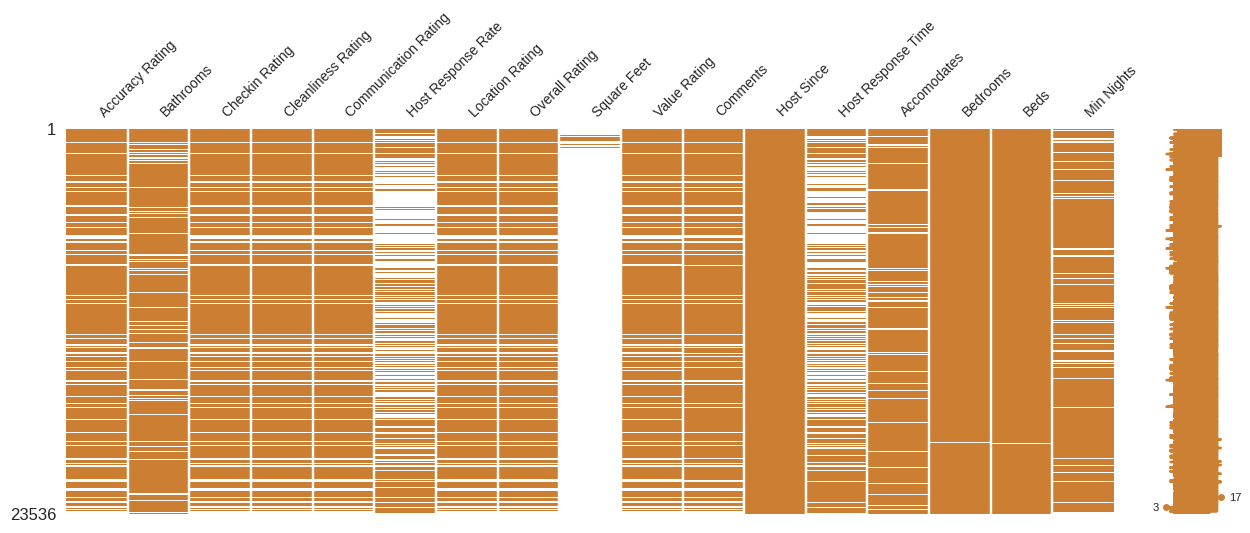

In [38]:
msno.matrix(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

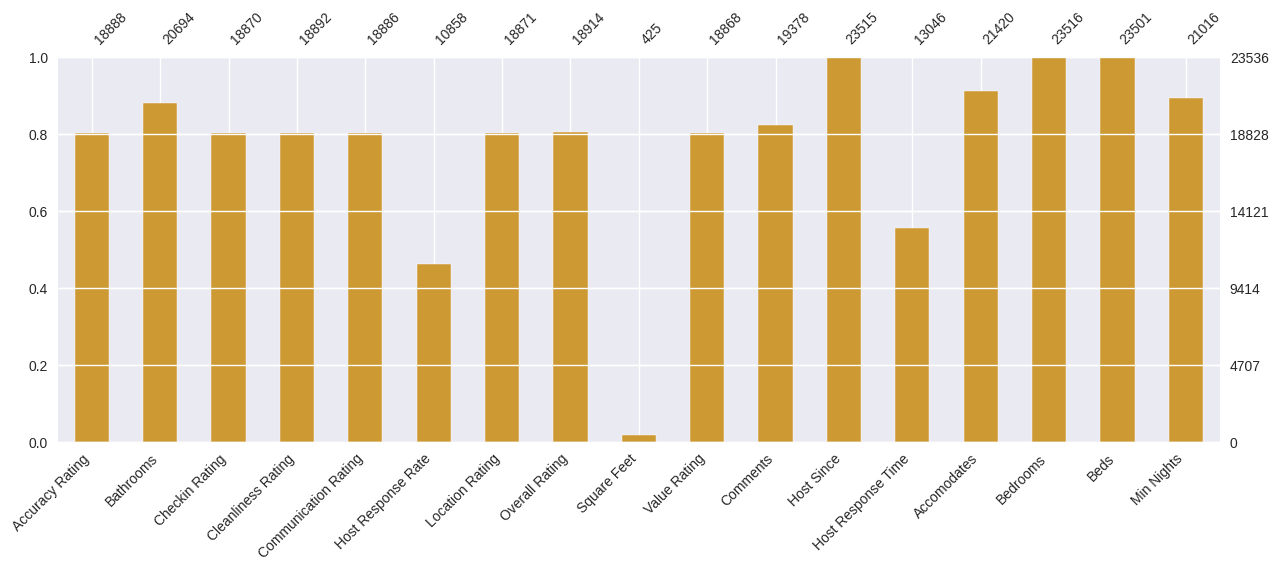

In [39]:
msno.bar(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.6, 0.2));

In [40]:
def missing_values_table(df):
  mis_val = df.isna().sum()
  mis_val_per = mis_val/len(df)*100
  mis_val_table = pd.concat([mis_val, mis_val_per], axis=1)
  mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
  mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,:] != 0].sort_values(
      '% of Total Values', ascending=False).round(1)
  return mis_val_table_ren_columns

mis_val_table_ren_columns = missing_values_table(df_nulls)
mis_val_table_ren_columns

,Missing Values,% of Total Values
Square Feet,23111,98.2
Host Response Rate,12678,53.9
Host Response Time,10490,44.6
Value Rating,4668,19.8
Checkin Rating,4666,19.8
Location Rating,4665,19.8
Communication Rating,4650,19.8
Accuracy Rating,4648,19.7
Cleanliness Rating,4644,19.7
Overall Rating,4622,19.6


Creating a dataframe with missing values as 1 and existing values as 0:

In [41]:
df_missing_data = manipulated_data.isin([np.nan])
df_missing_data = df_missing_data.astype('int')
df_missing_data

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,1,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
23532,1,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23533,1,1,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,1,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


Creating df including numeric features of the later data - manipulated_data

In [42]:
#Selecting numeric data
numeric_manipulated_data = manipulated_data.select_dtypes(include=[np.number])
numeric_manipulated_data.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews'],
      dtype='object')

## Exploring data

Difference in the distribution of a variable when another variable is with or without MV:

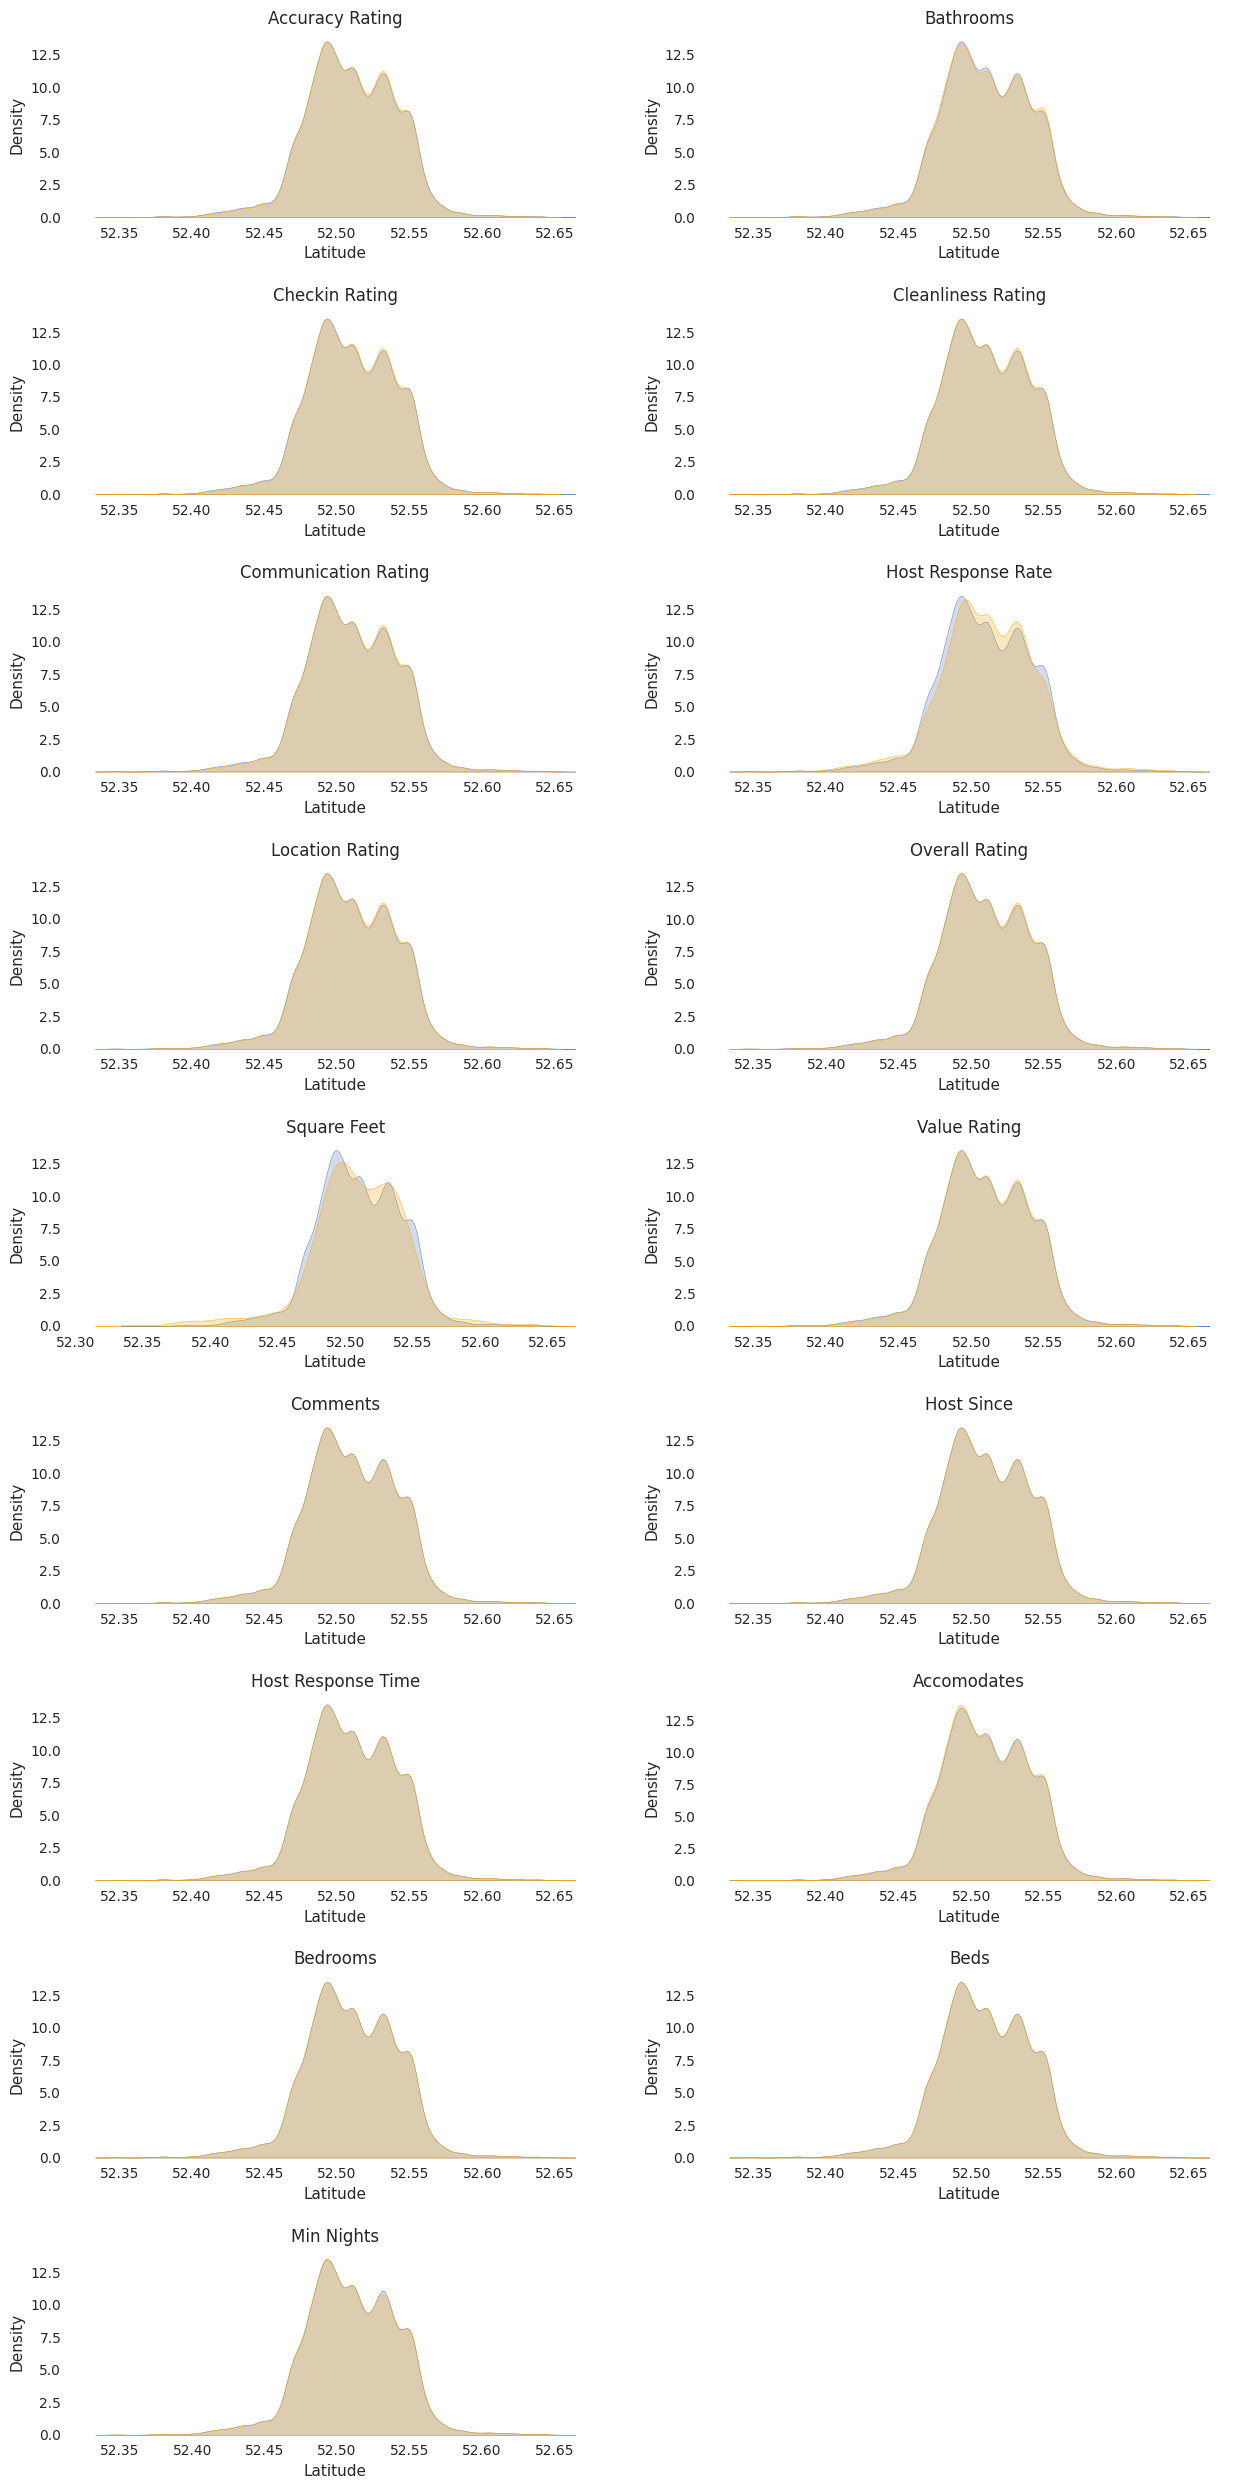

In [81]:
#c = numeric_manipulated_data.columns
colist = df_nulls.columns
#names = missing_names
#sns.set(font_scale = 0.8)
#sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set
a=len(colist)
b=2
c=1
fig = plt.figure(figsize=(15,60))
plt.subplots_adjust(hspace=0.5)
for j in df_nulls:
    plt.subplot(a,b,c)
    plt.title('{}'.format(j),fontsize=12)
    plt.xlabel(i)
    sns.kdeplot(df['Latitude'],fill=True)
    sns.kdeplot(df['Latitude'].loc[df_missing_data[j]==0],fill=True,color='orange')
    c=c+1

plt.show()

Exploring data of the segnificunce of distribution change:

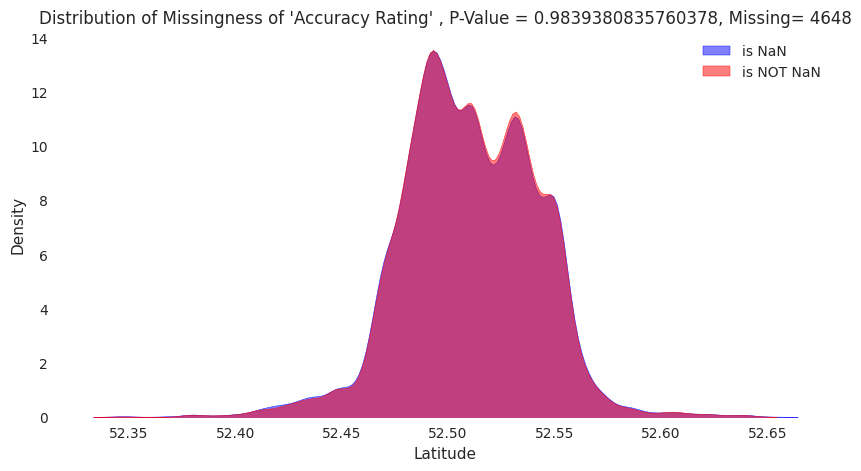

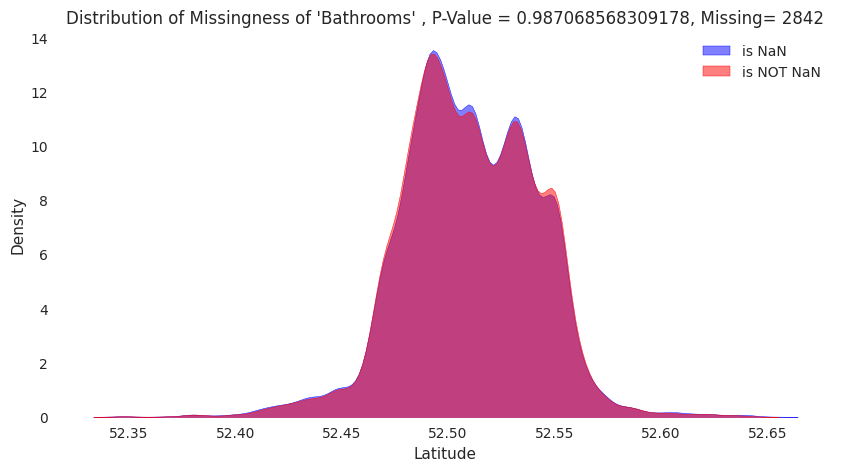

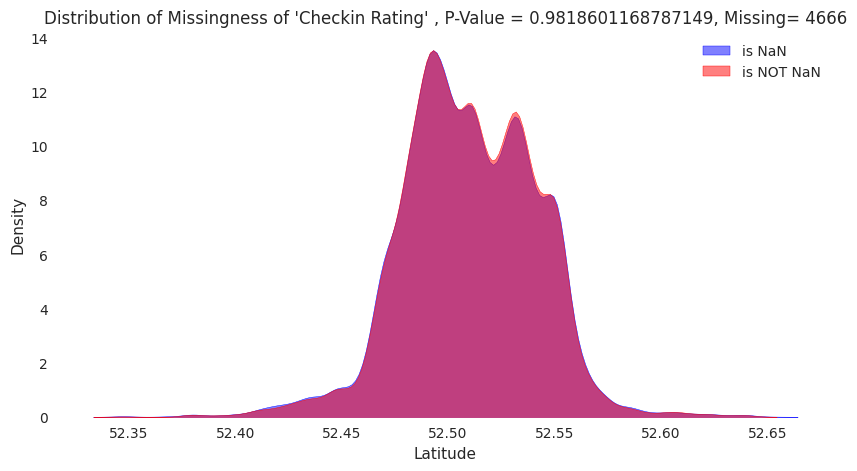

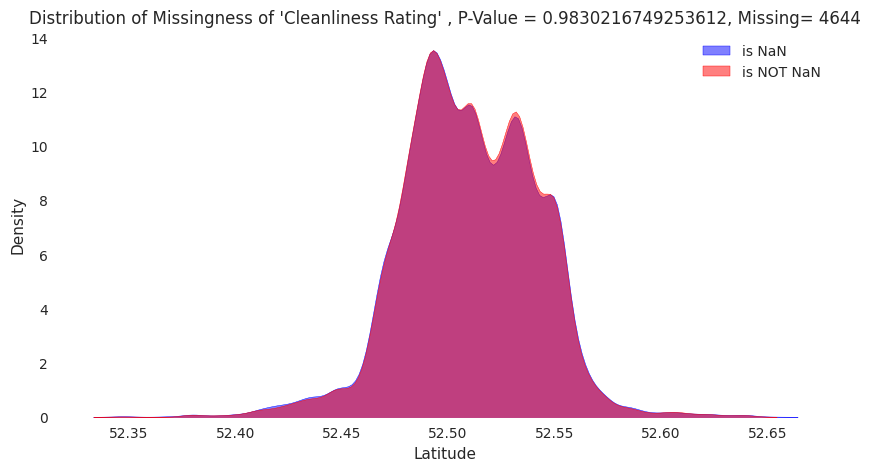

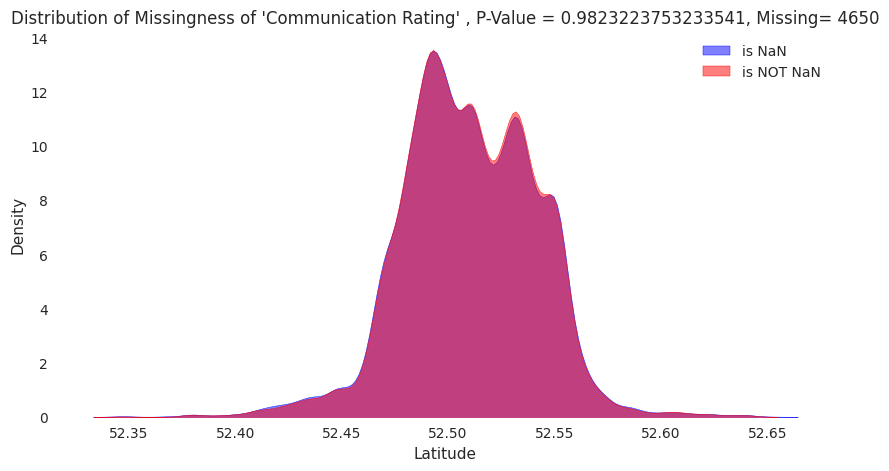

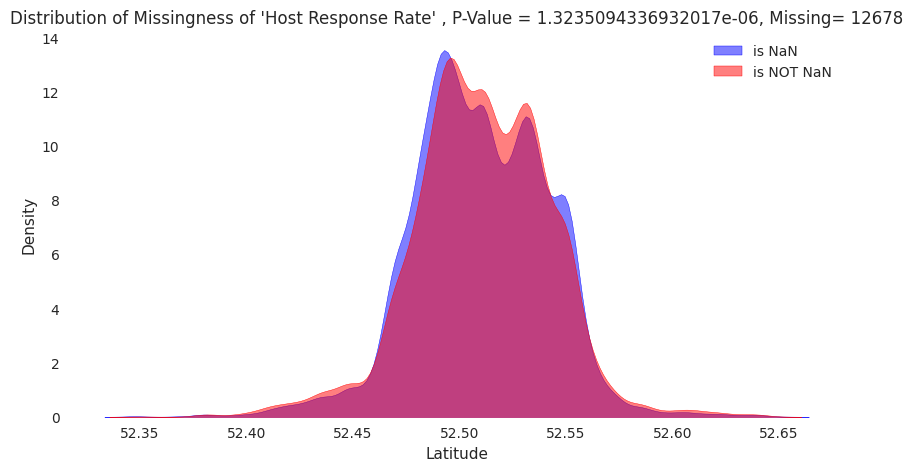

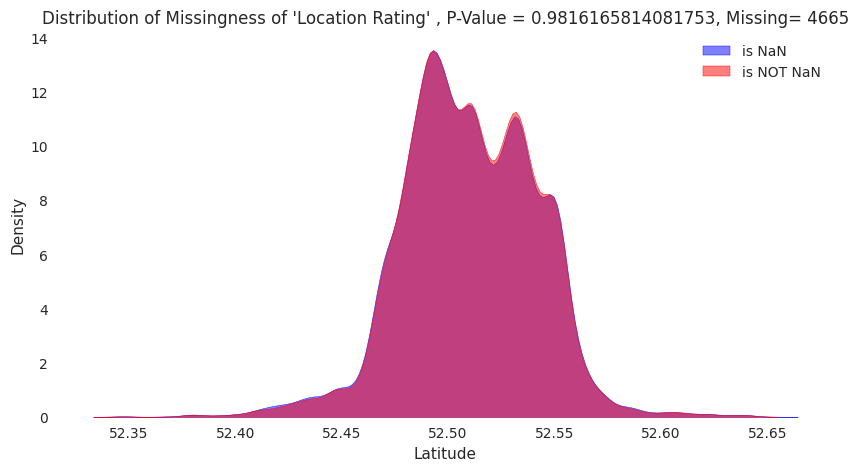

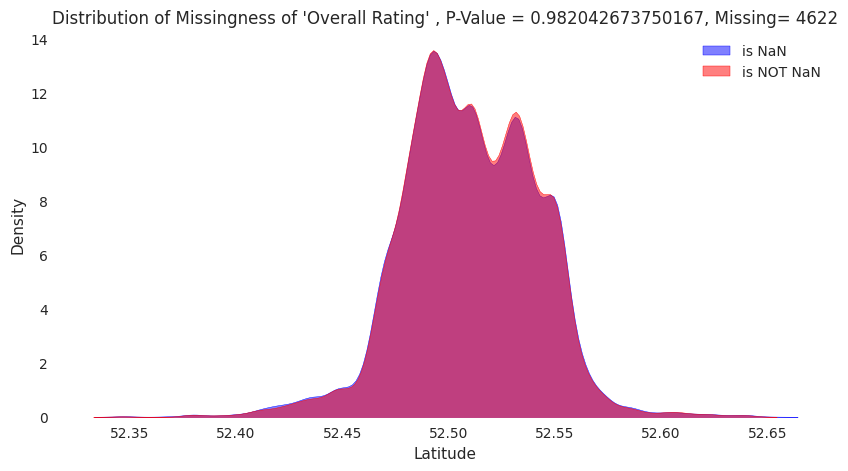

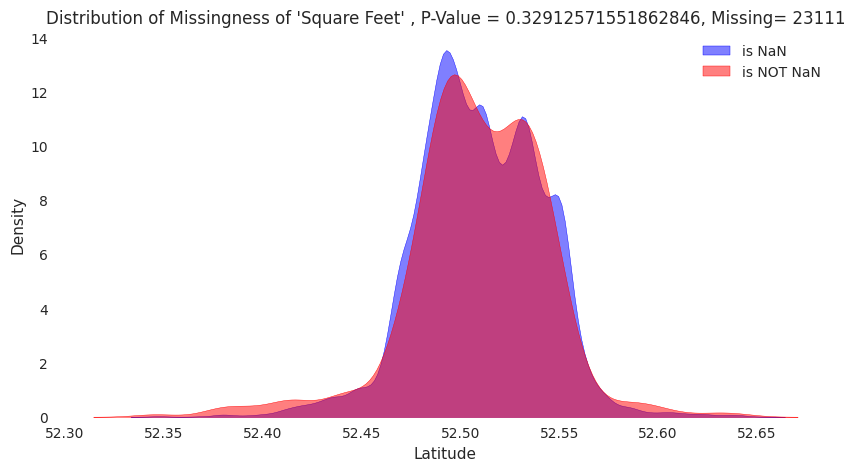

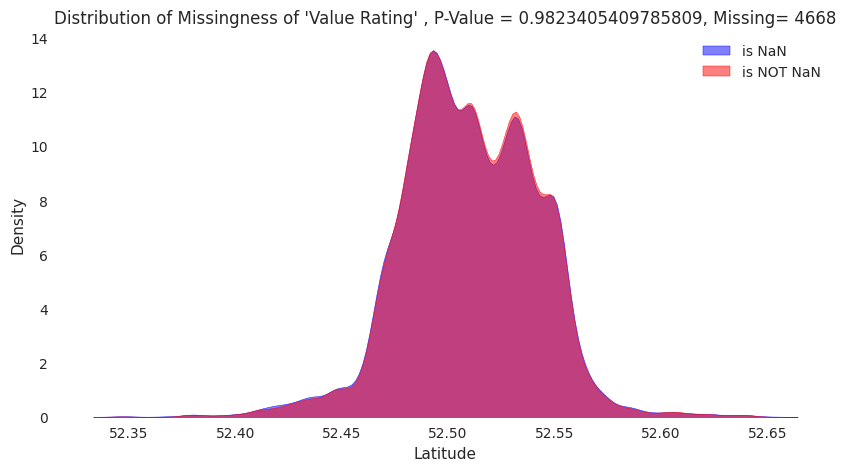

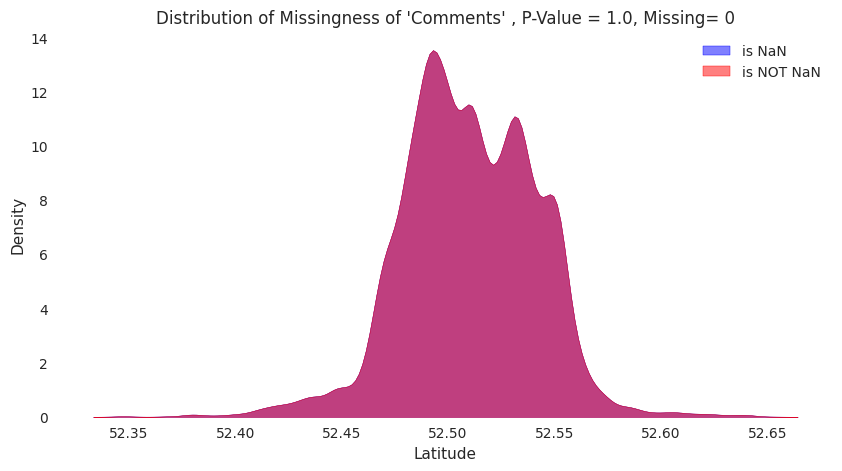

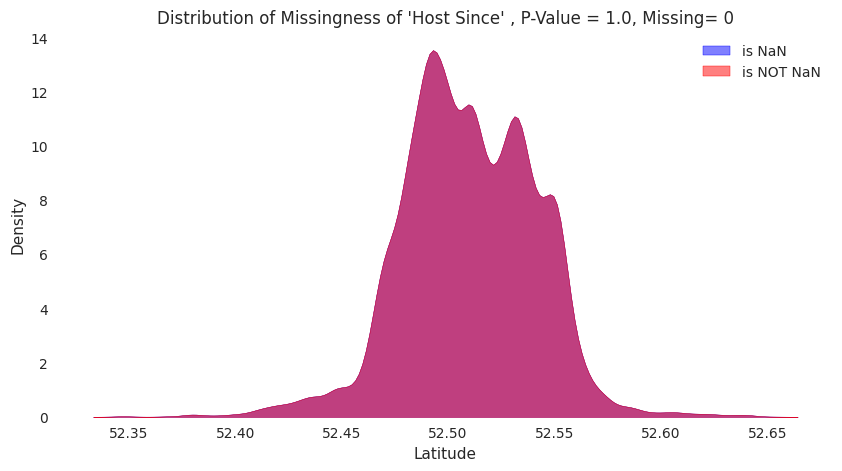

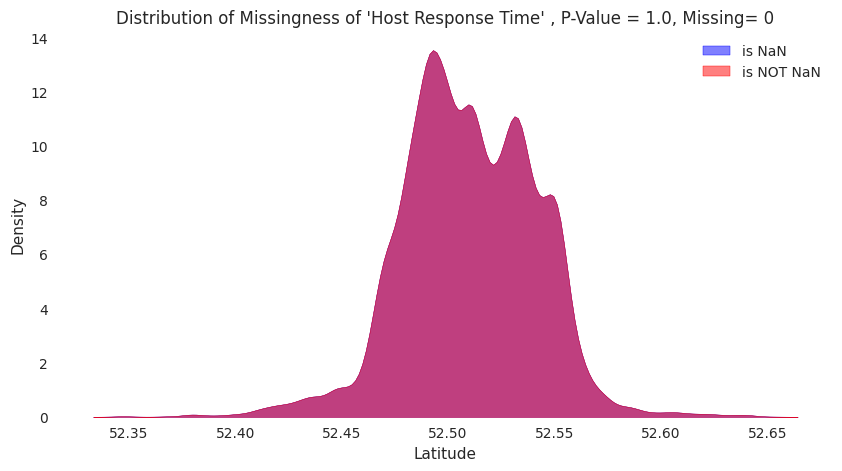

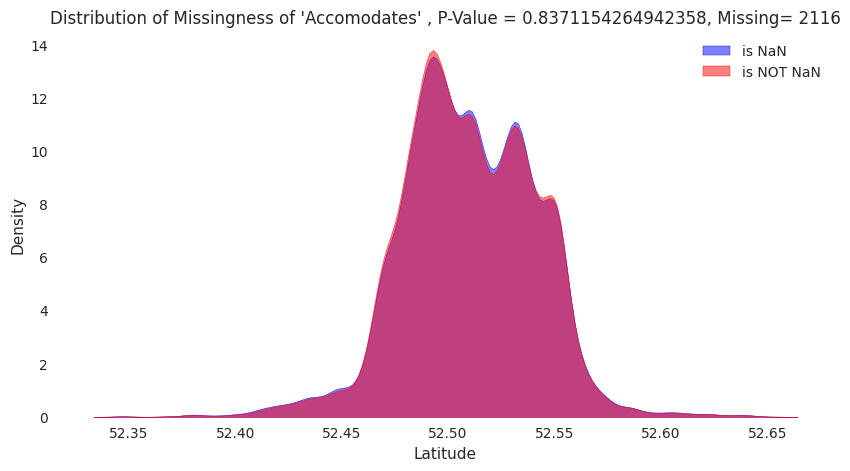

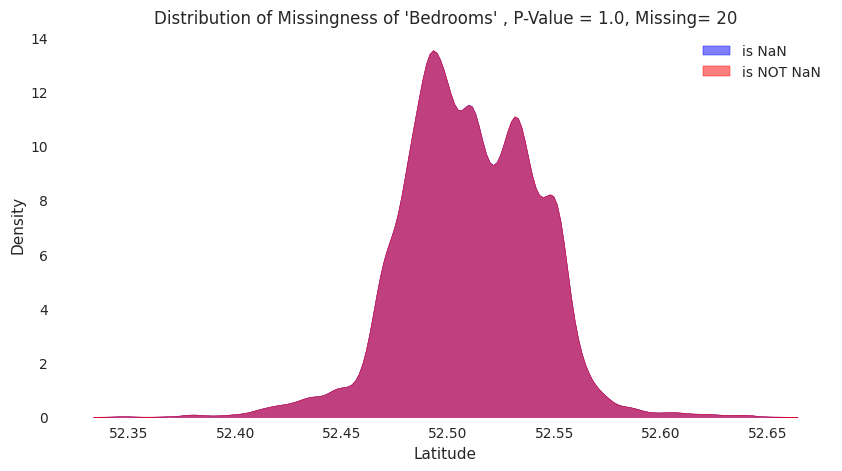

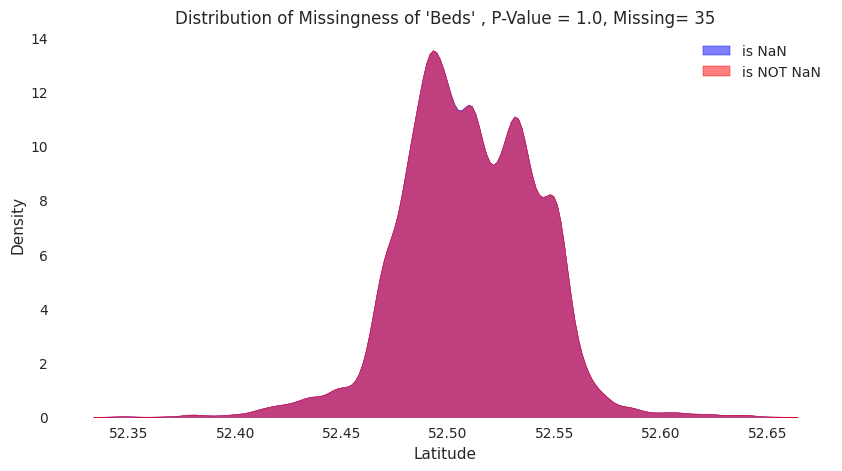

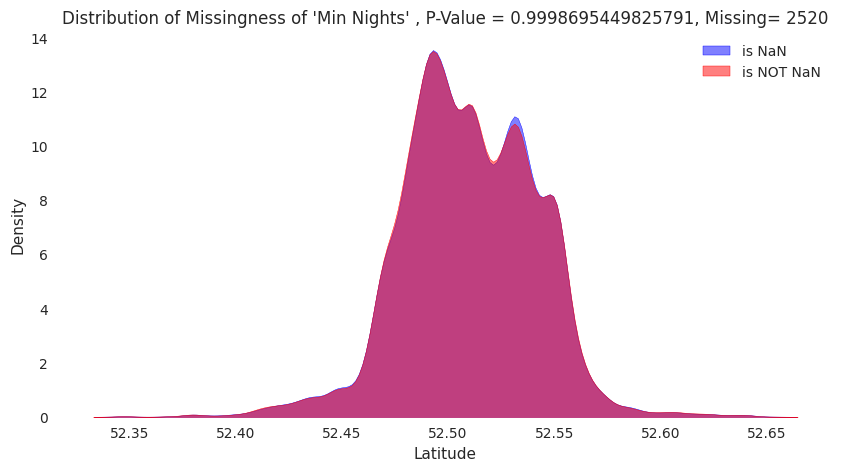

,Var,MV_pct,distribution_changed,pval
0,Accuracy Rating,4648,-,0.983938
1,Bathrooms,2842,-,0.987069
2,Checkin Rating,4666,-,0.981860
3,Cleanliness Rating,4644,-,0.983022
4,Communication Rating,4650,-,0.982322
5,Host Response Rate,12678,+,0.000001
6,Location Rating,4665,-,0.981617
7,Overall Rating,4622,-,0.982043
8,Square Feet,23111,-,0.329126
9,Value Rating,4668,-,0.982341


In [44]:
#le = preprocessing.LabelEncoder()
MV_df_final = pd.DataFrame(columns= ['Var', 'MV_pct', 'distribution_changed', 'pval'])
#df[m] = le.fit_transform(df[m].astype(str))
m=numeric_manipulated_data.copy()
#m = manipulated_data._get_numeric_data().columns.dropna().unique()
np.seterr(divide='ignore', invalid='ignore')
for i in df_nulls:
    # and i in mis_val_table_ren_columns.index.tolist():
    # column with NULLS
        null = m['Latitude'] ##.loc[df_missing_data[i]==1]
    # column without NULLS
        non = m['Latitude'].loc[df_missing_data[i]==0]
    # target value with NULLS
        price_null = m['Price']
    # target value without NULLS
        price_non = price_null.loc[df_missing_data[i]==0]
        mv = df_missing_data[i].sum()
    # perform Kolmogorov-Smirnov test
        pval = ks_2samp(null, non)[1]
        dis_change = np.where(pval<0.05,'+','-')
        # MV_df_final = pd.concat([MV_df_final, pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])], ignore_index=True)
        temp_df = pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change, 'pval': pval}, index=[0])
        # Concatenate the temporary DataFrame to the final DataFrame
        MV_df_final = pd.concat([MV_df_final, temp_df], ignore_index=True)
        MV_df_final = MV_df_final[MV_df_final['MV_pct'] > 0]

        ## Plot KDE for comparison
        plt.figure(figsize=(10, 5))
        sns.kdeplot(null, label="is NaN", fill=True, alpha=0.5, color='blue')
        sns.kdeplot(non, label="is NOT NaN", fill=True, alpha=0.5, color='red')
        plt.title(f"Distribution of Missingness of '{i}' , P-Value = {pval}, Missing= {mv}")
        plt.legend()
        plt.show()
MV_df_final

Original

In [45]:
MV_df_final['drop']= 'Yes'
MV_df_final['MV_type']= 'MCAR/MAR'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'drop']='No'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'MV_type']='MNAR'
MV_df_final = MV_df_final[MV_df_final['MV_pct']>0].sort_values(by='MV_pct', ascending=False)
MV_df_final

,Var,MV_pct,distribution_changed,pval,drop,MV_type
8,Square Feet,23111,-,0.329126,Yes,MCAR/MAR
5,Host Response Rate,12678,+,0.000001,No,MNAR
9,Value Rating,4668,-,0.982341,Yes,MCAR/MAR
2,Checkin Rating,4666,-,0.981860,Yes,MCAR/MAR
6,Location Rating,4665,-,0.981617,Yes,MCAR/MAR
4,Communication Rating,4650,-,0.982322,Yes,MCAR/MAR
0,Accuracy Rating,4648,-,0.983938,Yes,MCAR/MAR
3,Cleanliness Rating,4644,-,0.983022,Yes,MCAR/MAR
7,Overall Rating,4622,-,0.982043,Yes,MCAR/MAR
1,Bathrooms,2842,-,0.987069,Yes,MCAR/MAR


# Data Imputation

Although the columns were recommended for removal, we will go over teh columns one by one.

In [46]:
mis_val_table_ren_columns

,Missing Values,% of Total Values
Square Feet,23111,98.2
Host Response Rate,12678,53.9
Host Response Time,10490,44.6
Value Rating,4668,19.8
Checkin Rating,4666,19.8
Location Rating,4665,19.8
Communication Rating,4650,19.8
Accuracy Rating,4648,19.7
Cleanliness Rating,4644,19.7
Overall Rating,4622,19.6


In [47]:
df_final = manipulated_data

In [48]:
manipulated_data.index[-1]

23535

In [49]:
manipulated_data.reset_index(drop=True, inplace=True)

In [50]:
df_nulls.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Location Rating',
       'Overall Rating', 'Square Feet', 'Value Rating', 'Comments',
       'Host Since', 'Host Response Time', 'Accomodates', 'Bedrooms', 'Beds',
       'Min Nights'],
      dtype='object')

1. We will delete 'Host Response Rate' since the missing is nearly 50%, however we will try to keep 'Host Response Time', cause we might use it later

In [51]:
del df_final['Host Response Rate']
del df_final['Square Feet']

2. We will categorize the missing values of dummies and categorial values: host_has_profile_pic, host_identity_verified, host_is_superhost, host_response_time, host_neighbourhood, host_location.
2.1 Transporing missing values of 3 categorial columns into additional categoey 'Missing'

In [52]:
#host_response_time
# df_final['Host Response Time'] = df_final.apply(lambda row: row['Host Response Time'] if type(row['Host Response Time']) == str else 'missing', axis=1)
df_final['Host Response Time'] = df_final['Host Response Time'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Host Response Time'].isnull().sum()

np.int64(0)

In [53]:
#host_response_time
df_final['Comments'] = df_final['Comments'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Comments'].isnull().sum()

np.int64(0)

In [54]:
missing_values_table(missing_columns_df(df_final))

,Missing Values,% of Total Values
Value Rating,4668,19.8
Checkin Rating,4666,19.8
Location Rating,4665,19.8
Communication Rating,4650,19.8
Accuracy Rating,4648,19.7
Cleanliness Rating,4644,19.7
Overall Rating,4622,19.6
Bathrooms,2842,12.1
Min Nights,2520,10.7
Accomodates,2116,9.0


### Use KNN

The rest of the data is below 40% missing. hense we can imput. we will use KNN

In [55]:
final_df = df_final.copy()
imp_cols = final_df.select_dtypes(include = ['float64', 'int64']).columns
imp_cols = [col for col in imp_cols if col not in ['Longitude', 'Latitude']]
imp_cols

['Accuracy Rating',
 'Bathrooms',
 'Checkin Rating',
 'Cleanliness Rating',
 'Communication Rating',
 'Location Rating',
 'Overall Rating',
 'Price',
 'Value Rating',
 'Accomodates',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews']

In [56]:
final_df['Accomodates']

,Accomodates
0,2.0
1,4.0
2,2.0
3,NaN
4,1.0
...,...
23531,3.0
23532,2.0
23533,1.0
23534,NaN


In [57]:
import math
math.sqrt(math.sqrt(len(final_df)))

12.386059554439452

In [58]:
from sklearn.impute import KNNImputer
# metric='nan_euclidean'
knn_imputer = KNNImputer(n_neighbors=11, metric='nan_euclidean')
imputed_data = pd.DataFrame(knn_imputer.fit_transform(final_df[imp_cols]),columns = imp_cols)

In [59]:
final_df[imp_cols] = imputed_data

<Axes: >

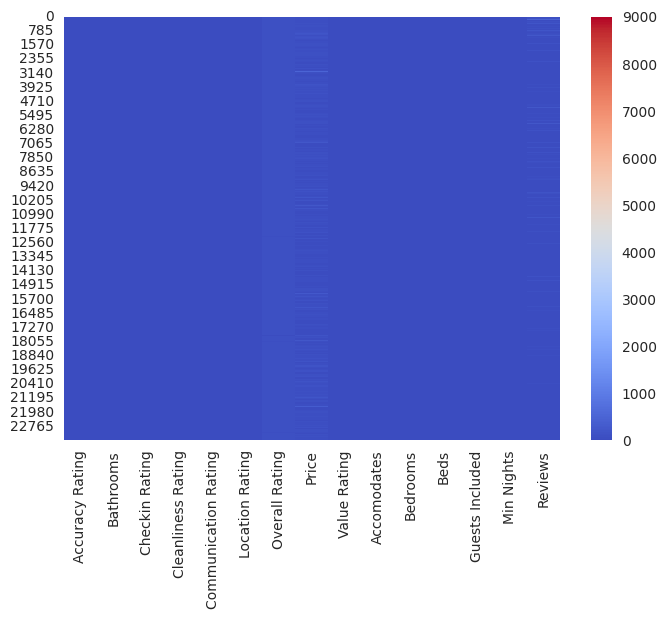

In [60]:
sns.heatmap(imputed_data, cmap="coolwarm")

In [61]:
imputed_data['Overall Rating'].notna().sum()

np.int64(23536)

In [62]:
print(f"df_final: {df_final.shape}, last_index: {df_final.index[-1]}")
print(f"final_df: {final_df.shape}, last_index: {final_df.index[-1]}")
print(f"imputed_data: {imputed_data.shape}, last_index: {imputed_data.index[-1]}")

df_final: (23536, 30), last_index: 23535
final_df: (23536, 30), last_index: 23535
imputed_data: (23536, 15), last_index: 23535


In [63]:
df_final.loc[df_final.index[-1]]

,23535
Accuracy Rating,NaN
Bathrooms,1.0
Checkin Rating,NaN
Cleanliness Rating,NaN
Communication Rating,NaN
Latitude,52.54929
Location Rating,NaN
Longitude,13.46067
Overall Rating,NaN
Price,65.0


In [64]:
# imputed_data.dropna(inplace=True)

In [65]:
imputed_data

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Price,Value Rating,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews
0,10.000000,1.0,10.000000,10.000000,10.000000,9.000000,100.000000,17.0,10.000000,2.000000,1.0,1.0,1.0,2.000000,7.0
1,9.000000,1.0,9.000000,9.000000,9.000000,10.000000,92.000000,90.0,9.000000,4.000000,1.0,2.0,2.0,1.727273,144.0
2,10.000000,1.0,10.000000,10.000000,10.000000,10.000000,96.000000,33.0,10.000000,2.000000,1.0,2.0,1.0,2.000000,229.0
3,10.000000,1.0,10.000000,10.000000,10.000000,10.000000,100.000000,180.0,10.000000,3.636364,4.0,7.0,5.0,6.000000,6.0
4,10.000000,1.0,9.000000,10.000000,10.000000,9.000000,93.000000,70.0,9.000000,1.000000,0.0,1.0,1.0,2.454545,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,9.818182,1.0,9.818182,9.272727,9.636364,9.454545,98.181818,48.0,9.272727,3.000000,1.0,2.0,1.0,2.363636,0.0
23532,9.272727,1.0,9.636364,7.818182,8.909091,8.727273,89.090909,30.0,9.090909,2.000000,2.0,2.0,2.0,5.000000,0.0
23533,10.000000,1.0,9.636364,9.272727,9.818182,9.272727,100.000000,17.0,8.909091,1.000000,1.0,1.0,1.0,2.000000,0.0
23534,8.909091,1.0,9.818182,9.181818,9.636364,9.181818,90.000000,52.0,8.909091,3.454545,3.0,4.0,1.0,2.000000,0.0


In [66]:
# final_df.loc[23531]
# final_df.iloc[23531]
final_df.loc[final_df.index[-1]]
final_df.index[-1]

23535

In [67]:
imputed_data.loc[imputed_data.index[-1]]
imputed_data.index[-1]

23535

In [68]:
df_final.shape, imputed_data.index[-1]

((23536, 30), 23535)

In [69]:
final_df.shape

(23536, 30)

In [70]:
imputed_data.shape, final_df.shape

((23536, 15), (23536, 30))

<Axes: >

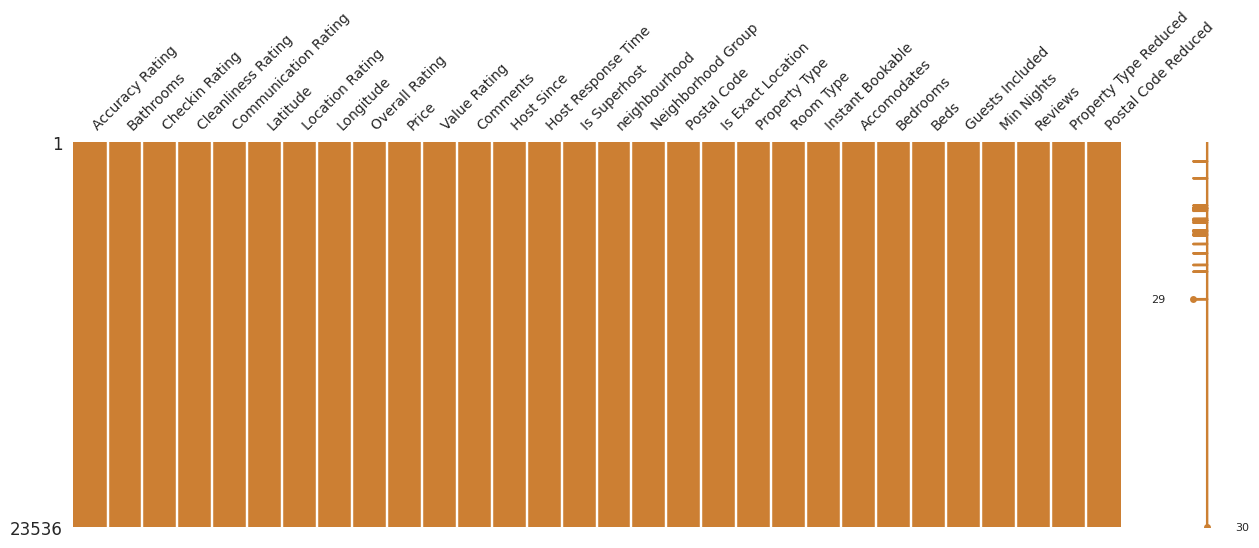

In [71]:
msno.matrix(final_df, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

# Next to Aggregation and Feature Engineering

In [72]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        23536 non-null  float64
 1   Bathrooms              23536 non-null  float64
 2   Checkin Rating         23536 non-null  float64
 3   Cleanliness Rating     23536 non-null  float64
 4   Communication Rating   23536 non-null  float64
 5   Latitude               23536 non-null  float64
 6   Location Rating        23536 non-null  float64
 7   Longitude              23536 non-null  float64
 8   Overall Rating         23536 non-null  float64
 9   Price                  23536 non-null  float64
 10  Value Rating           23536 non-null  float64
 11  Comments               23536 non-null  object 
 12  Host Since             23515 non-null  object 
 13  Host Response Time     23536 non-null  object 
 14  Is Superhost           23536 non-null  bool   
 15  ne

In [73]:
final_df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [74]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()

In [75]:
final_df[['Bedrooms', 'Beds', 'Accomodates']]

,Bedrooms,Beds,Accomodates
0,1.0,1.0,2.000000
1,1.0,2.0,4.000000
2,1.0,2.0,2.000000
3,4.0,7.0,3.636364
4,0.0,1.0,1.000000
...,...,...,...
23531,1.0,2.0,3.000000
23532,2.0,2.0,2.000000
23533,1.0,1.0,1.000000
23534,3.0,4.0,3.454545


# Candidate for Trash